# Automated MEP Ventilation Duct Routing Analysis

This analysis addresses three questions. First, whether the three pathfinding variants differ in computation time or output quality. Second, what the structural characteristics of the generated duct networks are across the evaluated apartments and floors. Third, how far the automated output deviates from the manually modelled benchmark. The analysis is based on routing metrics recorded from nine algorithm runs across three floors, supplemented by manually extracted metrics from the case study BIM model. Floor 3 serves as the primary evaluation floor because all six apartments and their manual baselines are fully available there. Floors 16 and 20 are used to verify cross-floor consistency and to extend the manual comparison where manual data is available.

In [46]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create directory for figures
FIGURES_DIR = './figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Set matplotlib rcParams for publication-style figures
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans'] # Changed Arial to DejaVu Sans as Arial is not found
plt.rcParams['font.size'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.dpi'] = 150 # For display

# Define color palette
colors = {
    'Dijkstra': '#2166AC',
    'Hybrid_AStar': '#D6604D',
    'Full_AStar': '#4DAF4A',
    'Supply': '#1A7A34',
    'Return': '#CC5500',
    'Manual': '#555555',
    'Floor 3': '#1F78B4',
    'Floor 16': '#33A02C',
    'Floor 20': '#E31A1C',
    'Trunk_Supply_Dark': '#1A5E28', # Darker shade of Supply
    'Branch_Supply_Light': '#6ABF7B', # Lighter shade of Supply
    'Trunk_Return_Dark': '#8B3300',  # Darker shade of Return
    'Branch_Return_Light': '#F0A060', # Lighter shade of Return
    'Manual_Dark_Grey': '#404040', # Darker grey for manual trunk
    'Manual_Light_Grey': '#808080' # Lighter grey for manual branch
}

## SECTION 0 — DATA SETUP

This section establishes the foundational datasets for the analysis, comprising automated routing metrics and manually modelled routing metrics. The data are structured into two pandas DataFrames for subsequent processing and comparison.

In [72]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Data for df_auto
data_auto = [
    # Floor 3, Dijkstra v7.3
    (3,'3.1','Dijkstra',38580.0,7.61,7875,5300,13175,3,0,3,16890,1700,18590,4,1,5),
    (3,'3.2','Dijkstra',35374.7,7.15,7825.6,10900,18725.6,3,5,8,9540.6,10900,20440.6,3,4,7),
    (3,'3.3','Dijkstra',33820.0,4.32,6364,8200,14564,1,0,1,3349,19500,22849,1,4,5),
    (3,'3.4','Dijkstra',37110.0,6.83,12347.5,9000,21347.5,3,4,7,17762.5,4800,22562.5,4,3,7),
    (3,'3.5','Dijkstra',35600.0,5.63,5915.5,15000,20915.5,2,4,6,5725.5,6800,12525.5,3,3,6),
    (3,'3.6','Dijkstra',34319.0,5.45,12232.5,10200,22432.5,6,3,9,8782.5,6600,15382.5,5,2,7),

    # Floor 3, Hybrid A* v7.3
    (3,'3.1','Hybrid_AStar',38580.0,7.34,7875,5300,13175,3,0,3,16890,1700,18590,4,1,5),
    (3,'3.2','Hybrid_AStar',35374.7,6.81,7825.6,10900,18725.6,3,5,8,9540.6,10900,20440.6,3,4,7),
    (3,'3.3','Hybrid_AStar',33820.0,4.18,6364,8200,14564,1,0,1,3349,19500,22849,1,4,5),
    (3,'3.4','Hybrid_AStar',37110.0,6.54,12347.5,9000,21347.5,3,4,7,17762.5,4800,22562.5,4,3,7),
    (3,'3.5','Hybrid_AStar',35600.0,5.38,5915.5,15000,20915.5,2,4,6,5725.5,6800,12525.5,3,3,6),
    (3,'3.6','Hybrid_AStar',34319.0,5.29,12232.5,10200,22432.5,6,3,9,8782.5,6600,15382.5,5,2,7),

    # Floor 3, Full A* v8.0
    (3,'3.1','Full_AStar',38580.0,5.25,7875,5300,13175,3,0,3,16890,1700,18590,4,1,5),
    (3,'3.2','Full_AStar',35374.7,4.64,7825.6,10900,18725.6,3,5,8,9340.6,10900,20240.6,3,4,7), # diff
    (3,'3.3','Full_AStar',33820.0,2.84,6364,8200,14564,1,0,1,3349,19500,22849,1,4,5), # diff
    (3,'3.4','Full_AStar',37110.0,4.55,12347.5,9000,21347.5,3,4,7,17762.5,4800,22562.5,4,3,7),
    (3,'3.5','Full_AStar',35600.0,3.62,5915.5,15000,20915.5,2,4,6,5725.5,6800,12525.5,3,3,6),
    (3,'3.6','Full_AStar',34319.0,3.48,12232.5,10200,22432.5,6,3,9,8782.5,6600,15382.5,5,2,7),

    # Floor 16, Dijkstra v7.3
    (16,'16.1','Dijkstra',38370.0,5.51,1975,14000,15975,1,4,5,4990,10100,15090,3,4,7),
    (16,'16.2','Dijkstra',35500.7,5.08,12362.6,9300,21662.6,4,3,7,13264.5,4500,17764.5,3,1,4),
    (16,'16.3','Dijkstra',42614.0,6.25,2474,23900,26374,1,5,6,3659,21200,24859,1,5,6),
    (16,'16.4','Dijkstra',47089.6,10.10,9341.3,13900,23241.3,6,6,12,5626.3,11500,17126.3,3,5,8),
    (16,'16.5','Dijkstra',33830.0,3.87,5512.5,14100,19612.5,1,5,6,11527.5,8400,19927.5,6,4,10),

    # Floor 16, Hybrid A* v7.3
    (16,'16.1','Hybrid_AStar',38370.0,5.57,1975,14000,15975,1,4,5,4990,10100,15090,3,4,7),
    (16,'16.2','Hybrid_AStar',35500.7,5.21,12362.6,9300,21662.6,4,3,7,13264.5,4500,17764.5,3,1,4),
    (16,'16.3','Hybrid_AStar',42614.0,6.45,2474,23900,26374,1,5,6,3659,21200,24859,1,5,6),
    (16,'16.4','Hybrid_AStar',47089.6,10.17,9341.3,13900,23241.3,6,6,12,5626.3,11500,17126.3,3,5,8),
    (16,'16.5','Hybrid_AStar',33830.0,3.87,5512.5,14100,19612.5,1,5,6,11527.5,8400,19927.5,6,4,10),

    # Floor 16, Full A* v8.0
    (16,'16.1','Full_AStar',38370.0,5.21,1975,14000,15975,1,4,5,4990,10100,15090,3,4,7),
    (16,'16.2','Full_AStar',35500.7,4.71,12362.6,9300,21662.6,4,3,7,13264.5,4400,17664.5,4,1,5), # diff
    (16,'16.3','Full_AStar',42614.0,5.84,2474,23900,26374,1,5,6,3659,21200,24859,1,5,6),
    (16,'16.4','Full_AStar',47089.6,9.43,9341.3,13900,23241.3,6,6,12,5626.3,11500,17126.3,3,5,8),
    (16,'16.5','Full_AStar',33830.0,3.44,5512.5,14100,19612.5,1,5,6,11527.5,8400,19927.5,6,4,10),

    # Floor 20, Dijkstra v7.3
    (20,'20.1','Dijkstra',38370.0,8.70,1975,14000,15975,1,4,5,4990,10100,15090,3,4,7),
    (20,'20.2','Dijkstra',35500.7,7.87,12362.6,9300,21662.6,4,3,7,13264.5,4500,17764.5,3,1,4),
    (20,'20.5','Dijkstra',33830.0,6.00,5512.5,14100,19612.5,1,5,6,11527.5,8400,19927.5,6,4,10),

    # Floor 20, Hybrid A* v7.3
    (20,'20.1','Hybrid_AStar',38370.0,6.09,1975,14000,15975,1,4,5,4990,10100,15090,3,4,7),
    (20,'20.2','Hybrid_AStar',35500.7,5.37,12362.6,9300,21662.6,4,3,7,13264.5,4500,17764.5,3,1,4),
    (20,'20.5','Hybrid_AStar',33830.0,4.42,5512.5,14100,19612.5,1,5,6,11527.5,8400,19927.5,6,4,10),

    # Floor 20, Full A* v8.0
    (20,'20.1','Full_AStar',38370.0,7.05,1975,14000,15975,1,4,5,4990,10100,15090,3,4,7),
    (20,'20.2','Full_AStar',35500.7,6.43,12362.6,9300,21662.6,4,3,7,13264.5,4400,17664.5,4,1,5), # diff
    (20,'20.5','Full_AStar',33830.0,4.66,5512.5,14100,19612.5,1,5,6,11527.5,8400,19927.5,6,4,10)
]

columns_auto = [
    'floor', 'apt_id', 'algorithm', 'perimeter_mm', 'runtime_s',
    'sup_trunk_mm', 'sup_branch_mm', 'sup_total_mm',
    'sup_trunk_turns', 'sup_branch_turns', 'sup_total_turns',
    'ret_trunk_mm', 'ret_branch_mm', 'ret_total_mm',
    'ret_trunk_turns', 'ret_branch_turns', 'ret_total_turns'
]

df_auto = pd.DataFrame(data_auto, columns=columns_auto)

# Load the new manual solution metrics from CSV
manual_csv_path = 'Manual solution metrics.csv'
df_manual = pd.read_csv(manual_csv_path, header=[0, 1])

# Clean and flatten multi-level columns
df_manual.columns = ['_'.join(col).strip() for col in df_manual.columns.values]

# Rename columns to a more usable format and handle specific cases
df_manual = df_manual.rename(columns={
    'Unnamed: 0_level_0_Apt Name': 'apt_id',
    'Supply_Total Length (mm)': 'sup_total_mm',
    'Supply_Total Turns': 'sup_total_turns',
    'Return_Total Length (mm)': 'ret_total_mm',
    'Return_Total Turns': 'ret_total_turns',
    'Supply_Trunk Length (mm)': 'sup_trunk_mm',
    'Supply_Branch Length (mm)': 'sup_branch_mm',
    'Return_Trunk Length (mm)': 'ret_trunk_mm',
    'Return_Branch Length (mm)': 'ret_branch_mm',
    'Supply_Elbows': 'sup_elbows', # Keep these for now if other cells use them
    'Return_Elbows': 'ret_elbows', # Keep these for now if other cells use them
    'Return_Tees': 'ret_tees',
    'Area_mm2': 'area_mm2',
    'Perimeter_mm': 'perimeter_mm'
})

# Drop columns that are entirely NaN, such as 'Unnamed: 9_level_1' or any leftover 'Unnamed' columns
df_manual = df_manual.loc[:, df_manual.notna().any(axis=0)]

# Extract floor from 'apt_id' and convert to integer
df_manual['floor'] = df_manual['apt_id'].apply(lambda x: int(x.split('_')[1].split('.')[0]))
# Clean apt_id to just 'X.Y'
df_manual['apt_id'] = df_manual['apt_id'].apply(lambda x: x.split('_')[1])

# Ensure all relevant columns are numeric, coerce errors will turn invalid parsing into NaN
numeric_cols = [
    'sup_trunk_mm', 'sup_branch_mm', 'sup_total_mm', 'sup_total_turns',
    'ret_trunk_mm', 'ret_branch_mm', 'ret_total_mm', 'ret_total_turns',
    'sup_elbows', 'ret_elbows', 'ret_tees', 'area_mm2', 'perimeter_mm'
]
for col in numeric_cols:
    if col in df_manual.columns:
        df_manual[col] = pd.to_numeric(df_manual[col], errors='coerce')

# Reorder columns for consistency if necessary, putting 'floor' and 'apt_id' first
df_manual = df_manual[['floor', 'apt_id'] + [col for col in df_manual.columns if col not in ['floor', 'apt_id']]]

print("df_auto head:")
display(df_auto.head())
print("\ndf_manual head:")
display(df_manual.head())

df_auto head:


,floor,apt_id,algorithm,perimeter_mm,runtime_s,sup_trunk_mm,sup_branch_mm,sup_total_mm,sup_trunk_turns,sup_branch_turns,sup_total_turns,ret_trunk_mm,ret_branch_mm,ret_total_mm,ret_trunk_turns,ret_branch_turns,ret_total_turns
0,3,3.1,Dijkstra,38580.0,7.61,7875.0,5300,13175.0,3,0,3,16890.0,1700,18590.0,4,1,5
1,3,3.2,Dijkstra,35374.7,7.15,7825.6,10900,18725.6,3,5,8,9540.6,10900,20440.6,3,4,7
2,3,3.3,Dijkstra,33820.0,4.32,6364.0,8200,14564.0,1,0,1,3349.0,19500,22849.0,1,4,5
3,3,3.4,Dijkstra,37110.0,6.83,12347.5,9000,21347.5,3,4,7,17762.5,4800,22562.5,4,3,7
4,3,3.5,Dijkstra,35600.0,5.63,5915.5,15000,20915.5,2,4,6,5725.5,6800,12525.5,3,3,6



df_manual head:


,floor,apt_id,Area_(m2),Perimeter_(mm),sup_trunk_mm,sup_branch_mm,sup_total_mm,Supply_Trunk Turns,Supply_Branch Turns,sup_total_turns,ret_trunk_mm,ret_branch_mm,ret_total_mm,Return_Trunk Turns,Return_Branch Turns,ret_total_turns
0,3,03.1,50.45,38580.0,3289.7,2689.4,5979.1,1.0,1.0,2.0,4262.2,3545.5,7807.7,4.0,3.0,7.0
1,3,03.2,67.75,35374.7,4607.9,4092.1,8700.0,0.0,2.0,2.0,13110.9,3299.6,16410.5,7.0,3.0,10.0
2,3,03.3,68.38,33820.0,5392.7,7475.4,12868.2,2.0,1.0,3.0,6929.1,4315.4,11244.5,3.0,2.0,5.0
3,3,03.4,59.37,37110.0,5608.9,3919.8,9528.6,2.0,1.0,3.0,1879.0,8136.3,10015.3,0.0,5.0,5.0
4,3,03.5,67.73,35600.0,5272.7,6917.9,12190.7,2.0,1.0,3.0,5372.1,4555.4,9927.5,3.0,2.0,5.0


## SECTION 1 — ALGORITHM COMPARISON

Three pathfinding variants were applied to all apartments across the three evaluated floors. The following figures compare their computation time and output quality.

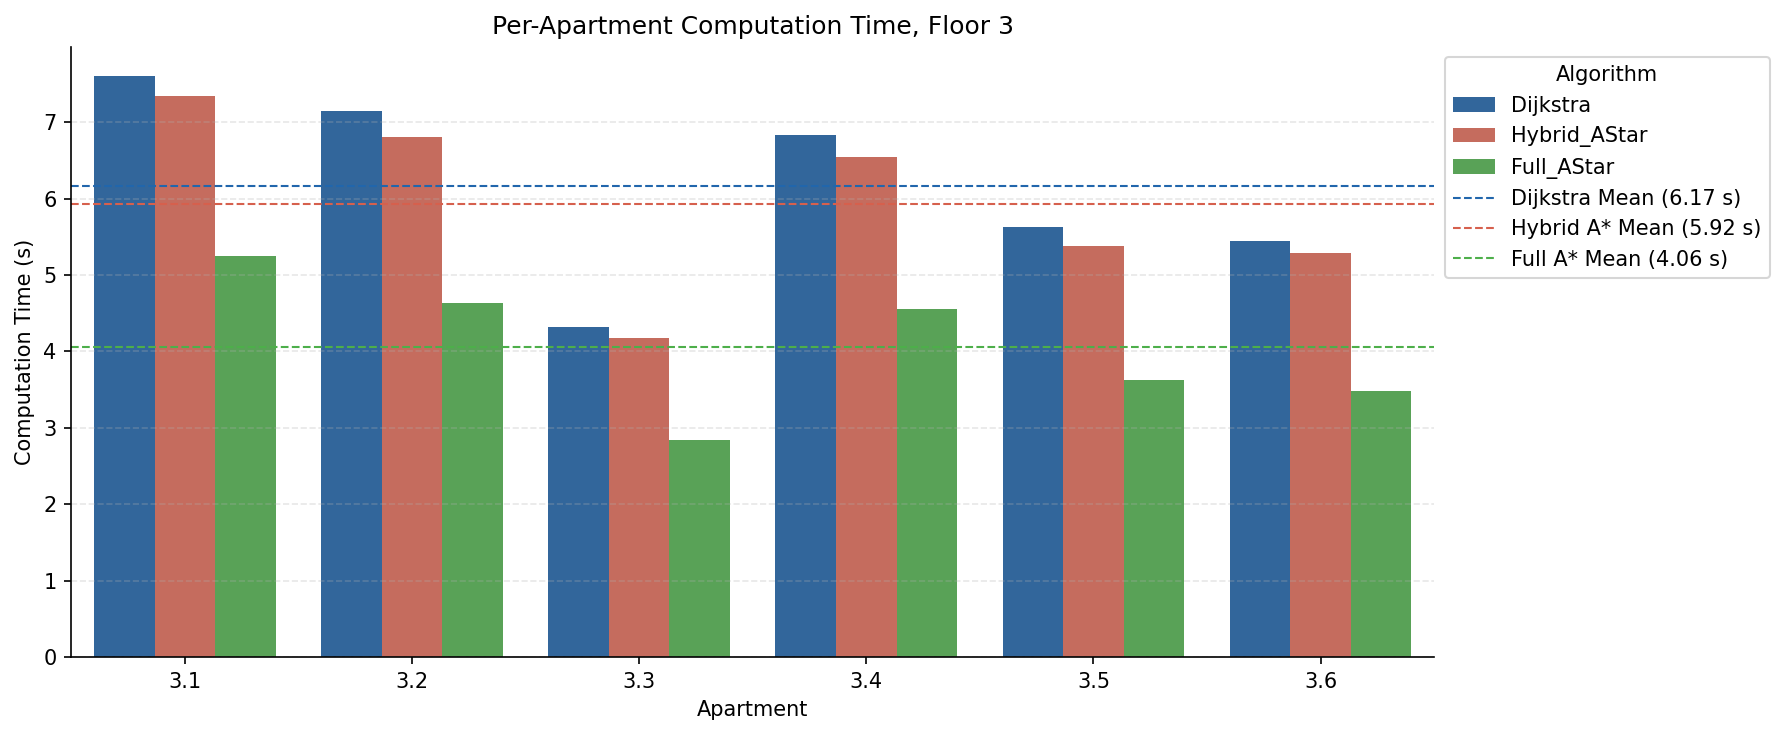

In [48]:
# @title
# Figure 1.1 — Grouped bar chart: Runtime per apartment, Floor 3 only, 3 algorithm bars.

df_floor3_runtime = df_auto[df_auto['floor'] == 3].copy()

# Calculate mean runtimes for horizontal lines
mean_dijkstra_runtime = df_floor3_runtime[df_floor3_runtime['algorithm'] == 'Dijkstra']['runtime_s'].mean()
mean_hybrid_runtime = df_floor3_runtime[df_floor3_runtime['algorithm'] == 'Hybrid_AStar']['runtime_s'].mean()
mean_full_astar_runtime = df_floor3_runtime[df_floor3_runtime['algorithm'] == 'Full_AStar']['runtime_s'].mean()

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=df_floor3_runtime,
    x='apt_id',
    y='runtime_s',
    hue='algorithm',
    palette={'Dijkstra': colors['Dijkstra'], 'Hybrid_AStar': colors['Hybrid_AStar'], 'Full_AStar': colors['Full_AStar']},
    ax=ax
)

ax.set_title('Per-Apartment Computation Time, Floor 3')
ax.set_xlabel('Apartment')
ax.set_ylabel('Computation Time (s)')

# Add horizontal dashed lines for mean runtime
ax.axhline(mean_dijkstra_runtime, color=colors['Dijkstra'], linestyle='--', linewidth=1, label=f'Dijkstra Mean ({mean_dijkstra_runtime:.2f} s)')
ax.axhline(mean_hybrid_runtime, color=colors['Hybrid_AStar'], linestyle='--', linewidth=1, label=f'Hybrid A* Mean ({mean_hybrid_runtime:.2f} s)')
ax.axhline(mean_full_astar_runtime, color=colors['Full_AStar'], linestyle='--', linewidth=1, label=f'Full A* Mean ({mean_full_astar_runtime:.2f} s)')

ax.legend(title='Algorithm', loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'Figure_1_1_Runtime_Floor3.png'), dpi=300)
plt.show()

*Figure 1.1: Per-Apartment Computation Time, Floor 3.*

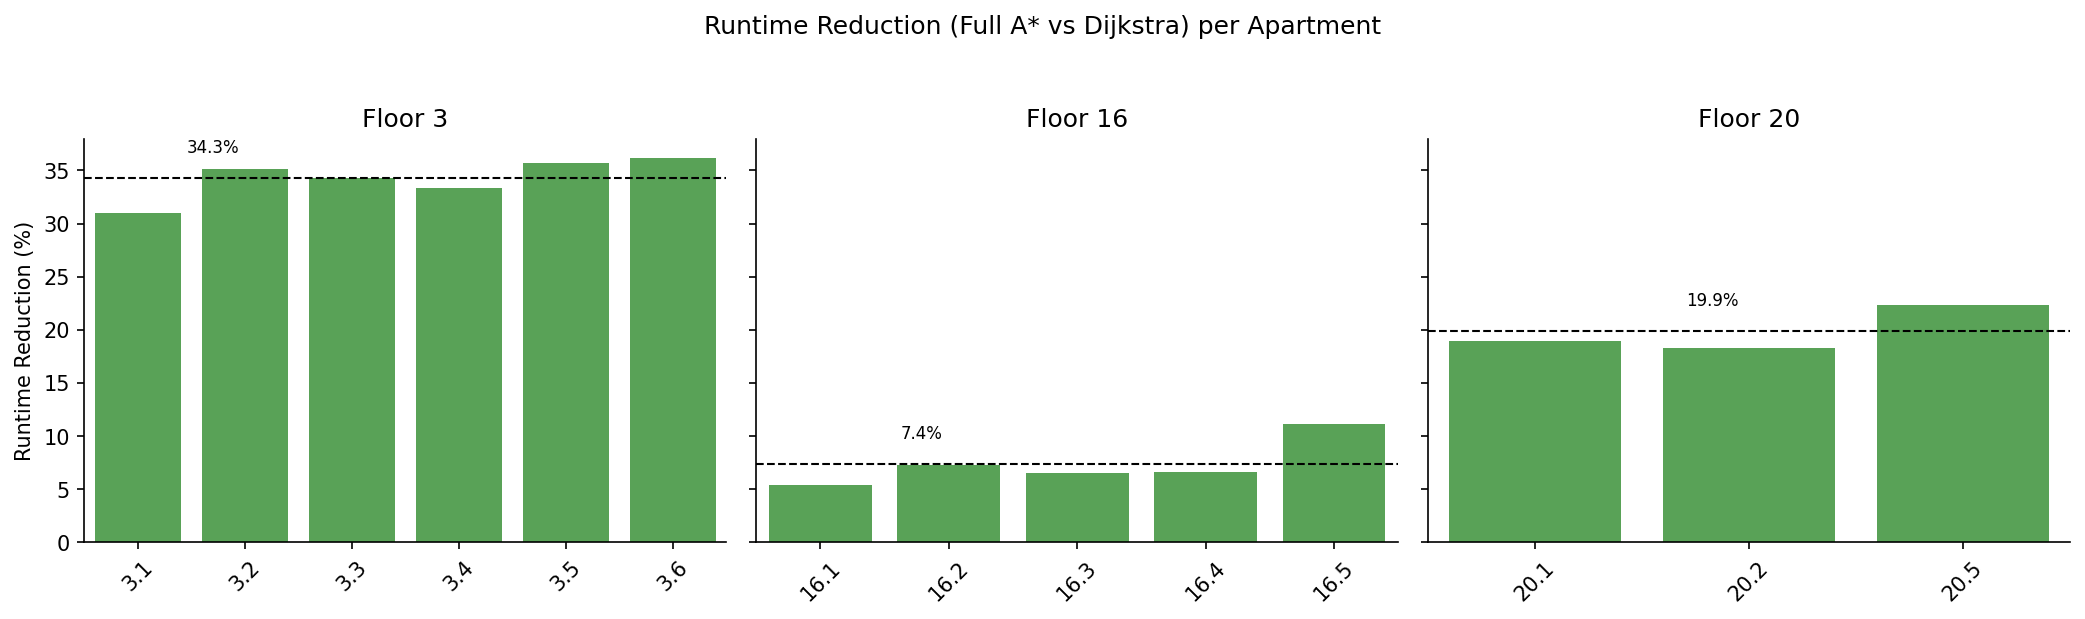

In [49]:
# @title
# Figure 1.2 — Three-panel figure: Bar chart of % runtime reduction (Full A* vs Dijkstra) per apartment.

# Calculate reduction
# Pivot table to get runtimes for Dijkstra and Full A*
pivoted_runtime = df_auto.pivot_table(index=['floor', 'apt_id'], columns='algorithm', values='runtime_s').reset_index()
pivoted_runtime = pivoted_runtime.rename(columns={'Dijkstra': 'Dijkstra_RT', 'Full_AStar': 'FullAStar_RT'})

pivoted_runtime['reduction_pct'] = ((pivoted_runtime['Dijkstra_RT'] - pivoted_runtime['FullAStar_RT']) / pivoted_runtime['Dijkstra_RT']) * 100

# Prepare data for plotting
floor_data = {
    3: pivoted_runtime[pivoted_runtime['floor'] == 3],
    16: pivoted_runtime[pivoted_runtime['floor'] == 16],
    20: pivoted_runtime[pivoted_runtime['floor'] == 20]
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
axes = axes.flatten()

for i, (floor, data) in enumerate(floor_data.items()):
    mean_reduction = data['reduction_pct'].mean()
    sns.barplot(
        data=data,
        x='apt_id',
        y='reduction_pct',
        color=colors['Full_AStar'], # Full A* color
        ax=axes[i]
    )
    axes[i].axhline(mean_reduction, color='black', linestyle='--', linewidth=1, label=f'Mean: {mean_reduction:.1f}%')
    axes[i].set_title(f'Floor {floor}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].annotate(f'{mean_reduction:.1f}%', (0.95, mean_reduction + 2), xycoords='data', ha='right', va='bottom', fontsize=8)

axes[0].set_ylabel('Runtime Reduction (%)')

plt.suptitle('Runtime Reduction (Full A* vs Dijkstra) per Apartment', y=1.02, fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(os.path.join(FIGURES_DIR, 'Figure_1_2_Runtime_Reduction.png'), dpi=300)
plt.show()


*Figure 1.2: Runtime Reduction (Full A\* vs Dijkstra) per Apartment.*

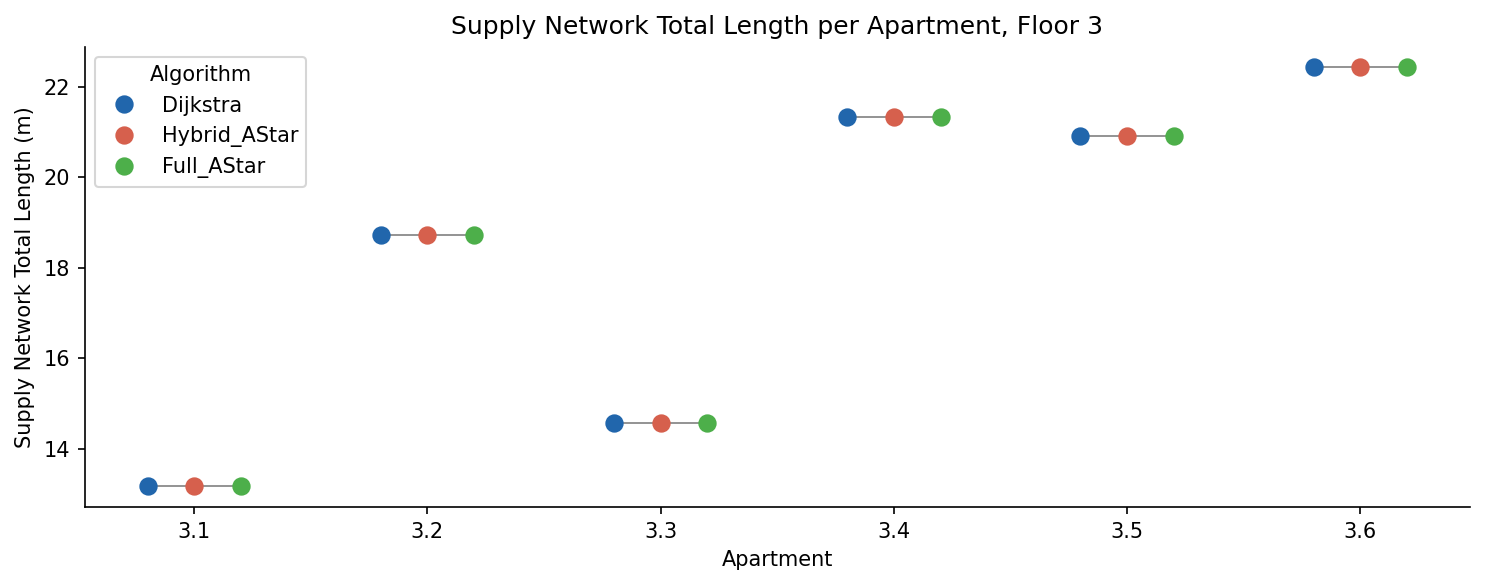

In [50]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Figure 1.3 — Dot plot: Supply total length comparison across 3 algorithms, per apartment (Floor 3 only).

df_floor3_supply = df_auto[df_auto['floor'] == 3].copy()
df_floor3_supply['sup_total_m'] = df_floor3_supply['sup_total_mm'] / 1000

fig, ax = plt.subplots(figsize=(10, 4))

# Plot the points first
sns.pointplot(
    data=df_floor3_supply,
    x='apt_id',
    y='sup_total_m',
    hue='algorithm',
    palette={'Dijkstra': colors['Dijkstra'], 'Hybrid_AStar': colors['Hybrid_AStar'], 'Full_AStar': colors['Full_AStar']},
    linestyle='none', # Use linestyle='none' instead of join=False
    dodge=0.4, # Dodge points for different algorithms
    ax=ax,
    markers='o',
    linestyles=''
)

# Manually connect dots within each apartment cluster with a thin grey line
# Get the unique apartment IDs and their sorted order as they appear on the x-axis
apt_ids_sorted = df_floor3_supply['apt_id'].unique()
algorithms_sorted = ['Dijkstra', 'Hybrid_AStar', 'Full_AStar'] # Ensure consistent order for dodging

# Calculate the actual x-positions for each algorithm within each apt_id category
# The number of hue categories
num_hues = len(algorithms_sorted)
# Calculate the offsets for each hue group based on the dodge width
dodge_width = 0.4 # This should match the dodge parameter in sns.pointplot
offsets = np.linspace(-dodge_width/2, dodge_width/2, num_hues)

for i, apt_id in enumerate(apt_ids_sorted):
    # Get the data for the current apartment across all algorithms
    apartment_data = df_floor3_supply[df_floor3_supply['apt_id'] == apt_id].copy()

    # Sort the data by algorithm to match the order of `offsets`
    apartment_data = apartment_data.set_index('algorithm').reindex(algorithms_sorted).reset_index()

    # Get the y-values (supply total in meters)
    y_values = apartment_data['sup_total_m'].values

    # Get the x-position for this apartment (categorical index on the x-axis)
    base_x_position = i

    # Apply the offsets to get the x-coordinates for each algorithm's point
    x_values_for_line = base_x_position + offsets

    # Plot the connecting line if all algorithm data is present
    if len(y_values) == num_hues and not np.isnan(y_values).any():
        ax.plot(x_values_for_line, y_values, color='grey', linewidth=0.8, zorder=0)

ax.set_title('Supply Network Total Length per Apartment, Floor 3')
ax.set_xlabel('Apartment')
ax.set_ylabel('Supply Network Total Length (m)')
ax.legend(title='Algorithm', loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'Figure_1_3_Supply_Length_Floor3.png'), dpi=300)
plt.show()

*Figure 1.3: Supply Network Total Length per Apartment, Floor 3.*

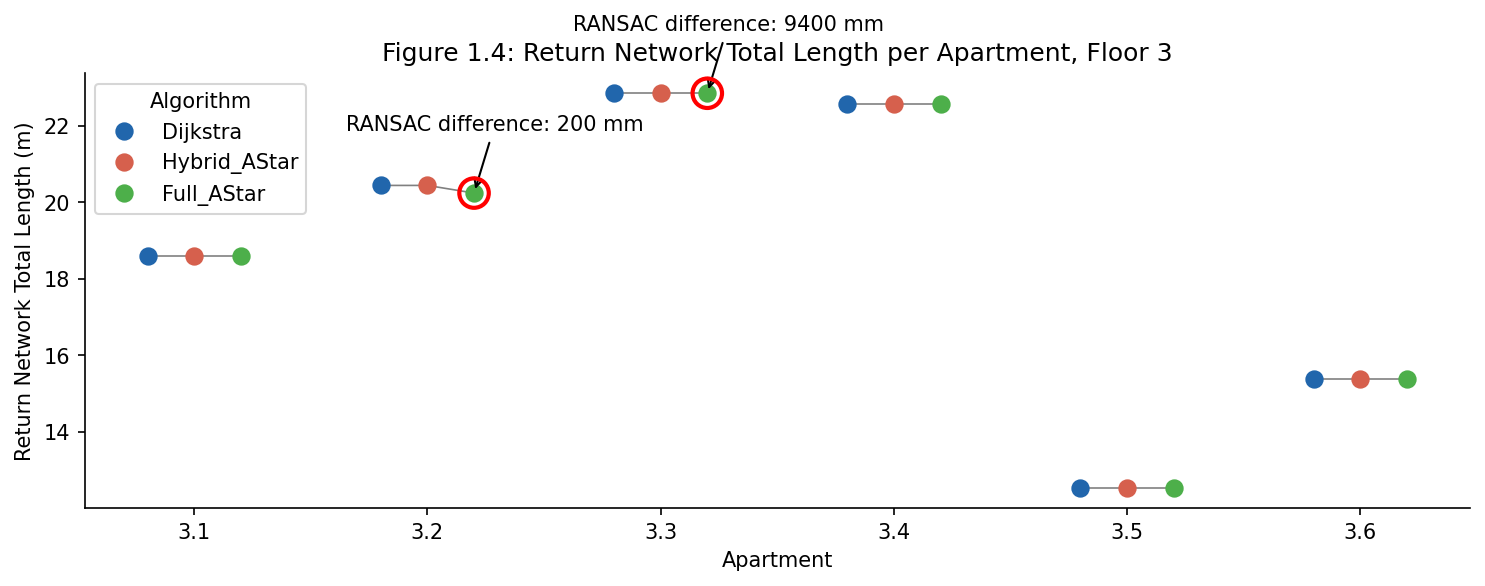

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Figure 1.4 — Same dot plot for Return total length (Floor 3) with annotations.

df_floor3_return = df_auto[df_auto['floor'] == 3].copy()
df_floor3_return['ret_total_m'] = df_floor3_return['ret_total_mm'] / 1000

fig, ax = plt.subplots(figsize=(10, 4))

sns.pointplot(
    data=df_floor3_return,
    x='apt_id',
    y='ret_total_m',
    hue='algorithm',
    palette={'Dijkstra': colors['Dijkstra'], 'Hybrid_AStar': colors['Hybrid_AStar'], 'Full_AStar': colors['Full_AStar']},
    linestyle='none', # Use linestyle='none' instead of join=False
    dodge=0.4,
    ax=ax,
    markers='o',
    linestyles=''
)

# Manually connect dots within each apartment cluster with a thin grey line
apt_ids_sorted = df_floor3_return['apt_id'].unique()
algorithms_sorted = ['Dijkstra', 'Hybrid_AStar', 'Full_AStar']
num_hues = len(algorithms_sorted)
dodge_width = 0.4
offsets = np.linspace(-dodge_width/2, dodge_width/2, num_hues)

for i, apt_id in enumerate(apt_ids_sorted):
    apartment_data = df_floor3_return[df_floor3_return['apt_id'] == apt_id].copy()
    apartment_data = apartment_data.set_index('algorithm').reindex(algorithms_sorted).reset_index()
    y_values = apartment_data['ret_total_m'].values
    base_x_position = i
    x_values_for_line = base_x_position + offsets

    if len(y_values) == num_hues and not np.isnan(y_values).any():
        ax.plot(x_values_for_line, y_values, color='grey', linewidth=0.8, zorder=0)

# Highlight and annotate differences for 3.2 and 3.3
for apt, diff_mm, text_label in [('3.2', 200, 'RANSAC difference: 200 mm'), ('3.3', 9400, 'RANSAC difference: 9400 mm')]:
    # Get the base x-position for the apartment category
    apt_idx = list(apt_ids_sorted).index(apt)
    base_x_pos = apt_idx

    # Get the x-offset for 'Full_AStar' algorithm
    full_astar_offset_idx = algorithms_sorted.index('Full_AStar')
    full_astar_x_pos = base_x_pos + offsets[full_astar_offset_idx]

    # Get the y-value for 'Full_AStar' for this apartment
    full_astar_y_val = df_floor3_return[
        (df_floor3_return['apt_id'] == apt) &
        (df_floor3_return['algorithm'] == 'Full_AStar')
    ]['ret_total_m'].iloc[0]

    # Add red circle marker
    ax.scatter(full_astar_x_pos, full_astar_y_val, s=200, facecolors='none', edgecolors='red', linewidths=2, zorder=5)

    # Add annotation
    ax.annotate(text_label, (full_astar_x_pos, full_astar_y_val), textcoords="offset points", xytext=(10, 30), ha='center', arrowprops=dict(arrowstyle='->', color='black'))


ax.set_title('Figure 1.4: Return Network Total Length per Apartment, Floor 3')
ax.set_xlabel('Apartment')
ax.set_ylabel('Return Network Total Length (m)')
ax.legend(title='Algorithm', loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'Figure_1_4_Return_Length_Floor3.png'), dpi=300)
plt.show()

*Figure 1.4: Return Network Total Length per Apartment, Floor 3.*

## SECTION 2 — NETWORK STRUCTURE

This section provides an analysis of the structural characteristics of the generated duct networks. Metrics such as the proportion of trunk versus branch lengths, the number of turns, and the ratio of return-to-supply network lengths are examined to elucidate the geometric properties and routing complexities inherent in the automated designs.

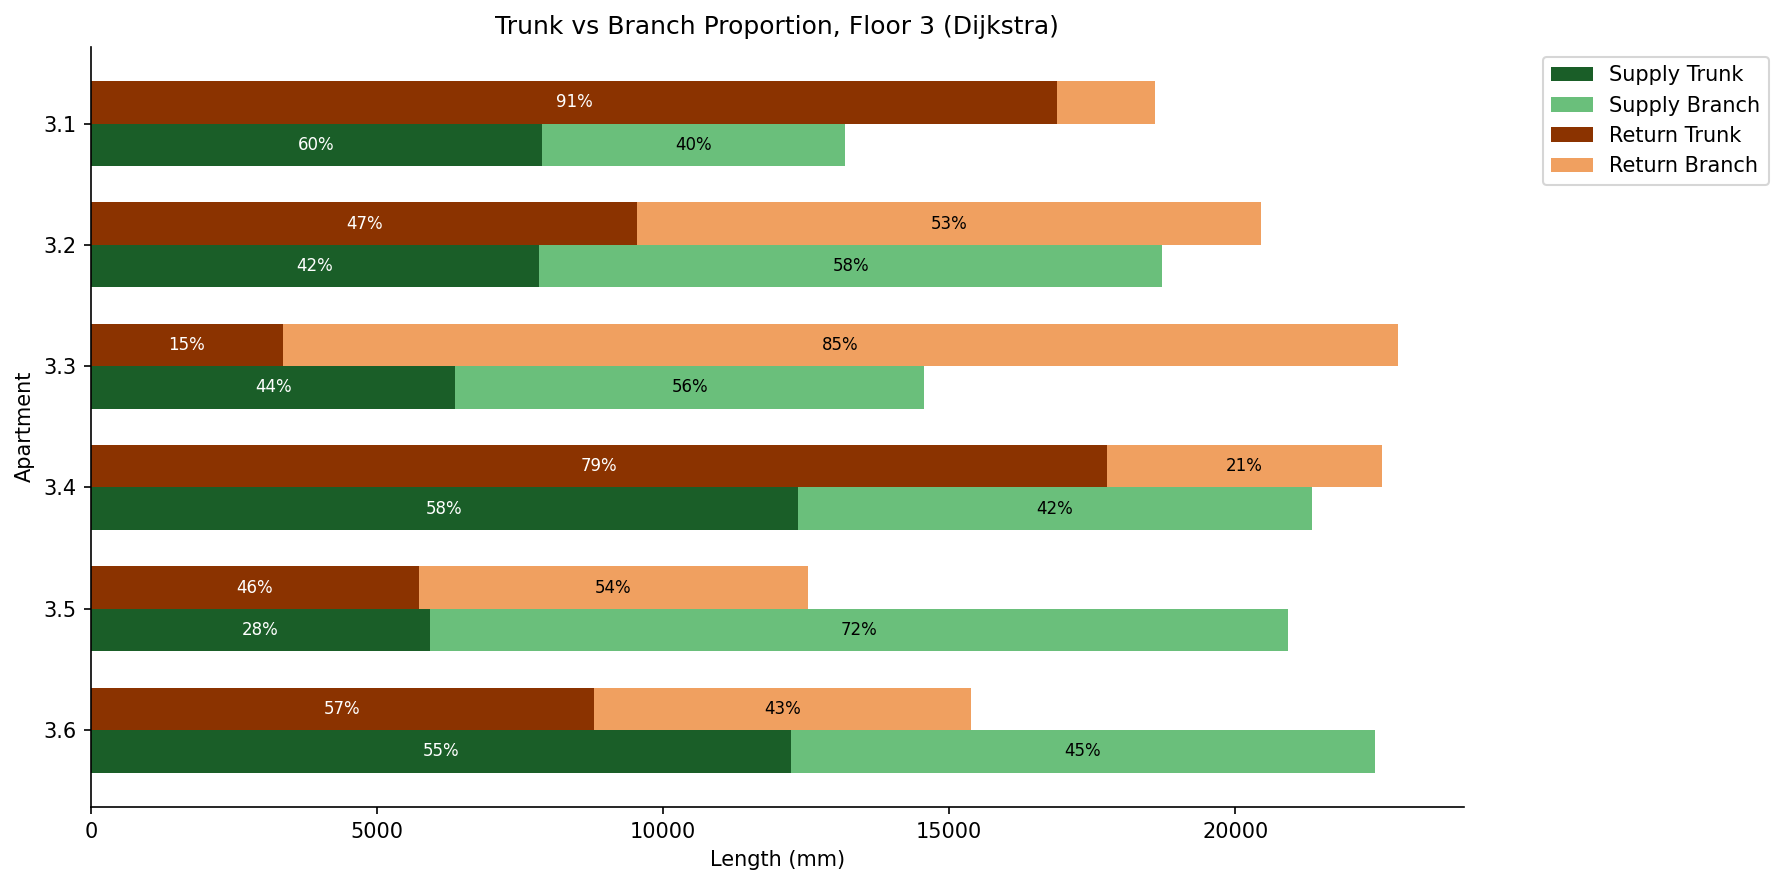

In [52]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Figure 2.1 — Stacked horizontal bar chart: Trunk vs Branch proportion for supply and return, per apartment (Floor 3, Dijkstra only).

df_dijkstra_floor3 = df_auto[(df_auto['floor'] == 3) & (df_auto['algorithm'] == 'Dijkstra')].copy()

# Prepare data for plotting
df_plot = pd.DataFrame({
    'apt_id': df_dijkstra_floor3['apt_id'],
    'sup_trunk_mm': df_dijkstra_floor3['sup_trunk_mm'],
    'sup_branch_mm': df_dijkstra_floor3['sup_branch_mm'],
    'ret_trunk_mm': df_dijkstra_floor3['ret_trunk_mm'],
    'ret_branch_mm': df_dijkstra_floor3['ret_branch_mm']
})

# Sort by apt_id for consistent plotting order
df_plot = df_plot.sort_values('apt_id').reset_index(drop=True)

# Calculate total lengths for percentages
df_plot['sup_total_mm'] = df_plot['sup_trunk_mm'] + df_plot['sup_branch_mm']
df_plot['ret_total_mm'] = df_plot['ret_trunk_mm'] + df_plot['ret_branch_mm']

fig, ax = plt.subplots(figsize=(12, 6))

bar_height = 0.35
y_pos = np.arange(len(df_plot))

# Plot Supply bars
ax.barh(y_pos + bar_height/2, df_plot['sup_trunk_mm'], height=bar_height, color=colors['Trunk_Supply_Dark'], label='Supply Trunk')
ax.barh(y_pos + bar_height/2, df_plot['sup_branch_mm'], height=bar_height, left=df_plot['sup_trunk_mm'], color=colors['Branch_Supply_Light'], label='Supply Branch')

# Plot Return bars
ax.barh(y_pos - bar_height/2, df_plot['ret_trunk_mm'], height=bar_height, color=colors['Trunk_Return_Dark'], label='Return Trunk')
ax.barh(y_pos - bar_height/2, df_plot['ret_branch_mm'], height=bar_height, left=df_plot['ret_trunk_mm'], color=colors['Branch_Return_Light'], label='Return Branch')

# Add percentage labels
for i, row in df_plot.iterrows():
    # Supply labels
    sup_trunk_pct = (row['sup_trunk_mm'] / row['sup_total_mm']) * 100
    sup_branch_pct = (row['sup_branch_mm'] / row['sup_total_mm']) * 100

    if sup_trunk_pct > 10:
        ax.text(row['sup_trunk_mm'] / 2, y_pos[i] + bar_height/2, f'{sup_trunk_pct:.0f}%', va='center', ha='center', color='white', fontsize=8)
    if sup_branch_pct > 10:
        ax.text(row['sup_trunk_mm'] + row['sup_branch_mm'] / 2, y_pos[i] + bar_height/2, f'{sup_branch_pct:.0f}%', va='center', ha='center', color='black', fontsize=8)

    # Return labels
    ret_trunk_pct = (row['ret_trunk_mm'] / row['ret_total_mm']) * 100
    ret_branch_pct = (row['ret_branch_mm'] / row['ret_total_mm']) * 100

    if ret_trunk_pct > 10:
        ax.text(row['ret_trunk_mm'] / 2, y_pos[i] - bar_height/2, f'{ret_trunk_pct:.0f}%', va='center', ha='center', color='white', fontsize=8)
    if ret_branch_pct > 10:
        ax.text(row['ret_trunk_mm'] + row['ret_branch_mm'] / 2, y_pos[i] - bar_height/2, f'{ret_branch_pct:.0f}%', va='center', ha='center', color='black', fontsize=8)


ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot['apt_id'])
ax.set_xlabel('Length (mm)')
ax.set_ylabel('Apartment')
ax.set_title('Trunk vs Branch Proportion, Floor 3 (Dijkstra)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.invert_yaxis() # To have '3.1' at the top

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'Figure_2_1_Trunk_Branch_Proportion_Floor3.png'), dpi=300)
plt.show()

*Figure 2.1: Trunk vs Branch Proportion, Floor 3 (Dijkstra).*

In apartment 3.5, branch paths account for 72 percent of the supply network, reflecting a layout where air terminals are distributed at a significant distance from the trunk corridor. Conversely, in apartment 3.4, the trunk accounts for 58 percent of supply, indicating a more centrally routed main duct. The return network in apartment 3.3 shows an extreme branch-dominant distribution (85 percent branch), caused by a short trunk positioned close to the DucoBox and long individual branches reaching each terminal.

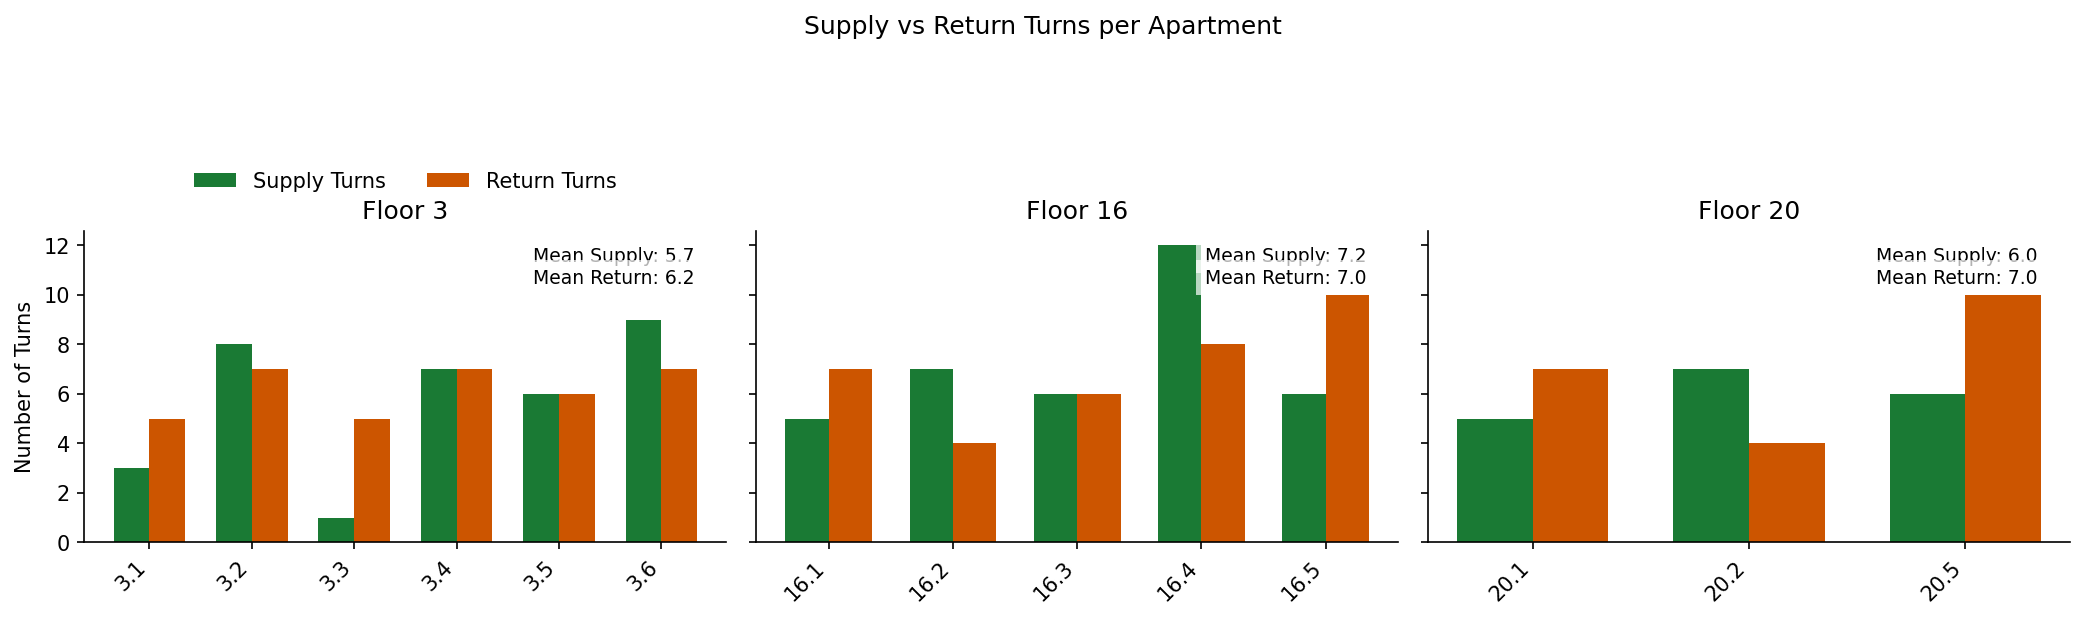

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Figure 2.2 — Grouped bar: Supply turns vs Return turns per apartment (Dijkstra, all three floors combined in one figure, subplots or faceted).

df_dijkstra_all_floors = df_auto[df_auto['algorithm'] == 'Dijkstra'].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
axes = axes.flatten()

for i, floor in enumerate(sorted(df_dijkstra_all_floors['floor'].unique())):
    ax = axes[i]
    df_floor = df_dijkstra_all_floors[df_dijkstra_all_floors['floor'] == floor].copy()

    # Sort apartments for consistent display, especially for floors with mixed IDs (e.g., 20.1, 20.2, 20.5)
    df_floor['apt_id_numeric'] = df_floor['apt_id'].apply(lambda x: float(x))
    df_floor = df_floor.sort_values('apt_id_numeric').reset_index(drop=True)

    apt_ids = df_floor['apt_id']
    supply_turns = df_floor['sup_total_turns']
    return_turns = df_floor['ret_total_turns']

    bar_width = 0.35
    ind = np.arange(len(apt_ids))

    ax.bar(ind - bar_width/2, supply_turns, bar_width, label='Supply Turns', color=colors['Supply'])
    ax.bar(ind + bar_width/2, return_turns, bar_width, label='Return Turns', color=colors['Return'])

    ax.set_title(f'Floor {floor}')
    ax.set_xticks(ind)
    ax.set_xticklabels(apt_ids, rotation=45, ha='right')
    ax.set_xlabel('') # Remove subplot x-label, use main x-label if needed

    # Annotate mean values
    mean_sup_turns = supply_turns.mean()
    mean_ret_turns = return_turns.mean()
    ax.text(0.95, 0.95, f'Mean Supply: {mean_sup_turns:.1f}', transform=ax.transAxes, ha='right', va='top', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    ax.text(0.95, 0.88, f'Mean Return: {mean_ret_turns:.1f}', transform=ax.transAxes, ha='right', va='top', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

axes[0].set_ylabel('Number of Turns')
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, frameon=False)

plt.suptitle('Supply vs Return Turns per Apartment', y=1.05, fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig(os.path.join(FIGURES_DIR, 'Figure_2_2_Turns_Comparison.png'), dpi=300)
plt.show()

*Figure 2.2: Supply vs Return Turns per Apartment.*

Return networks consistently exhibit more direction changes than supply networks. Across all 14 apartments, the mean supply turn count is approximately 6.3 and the mean return turn count is approximately 6.6. This asymmetry arises because supply routing is performed first, and the clearance buffer applied around supply path cells restricts the routing domain available to the return planner. Apartment 16.5 shows the largest imbalance, with 6 supply turns and 10 return turns.

/tmp/ipykernel_1996/3614130979.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


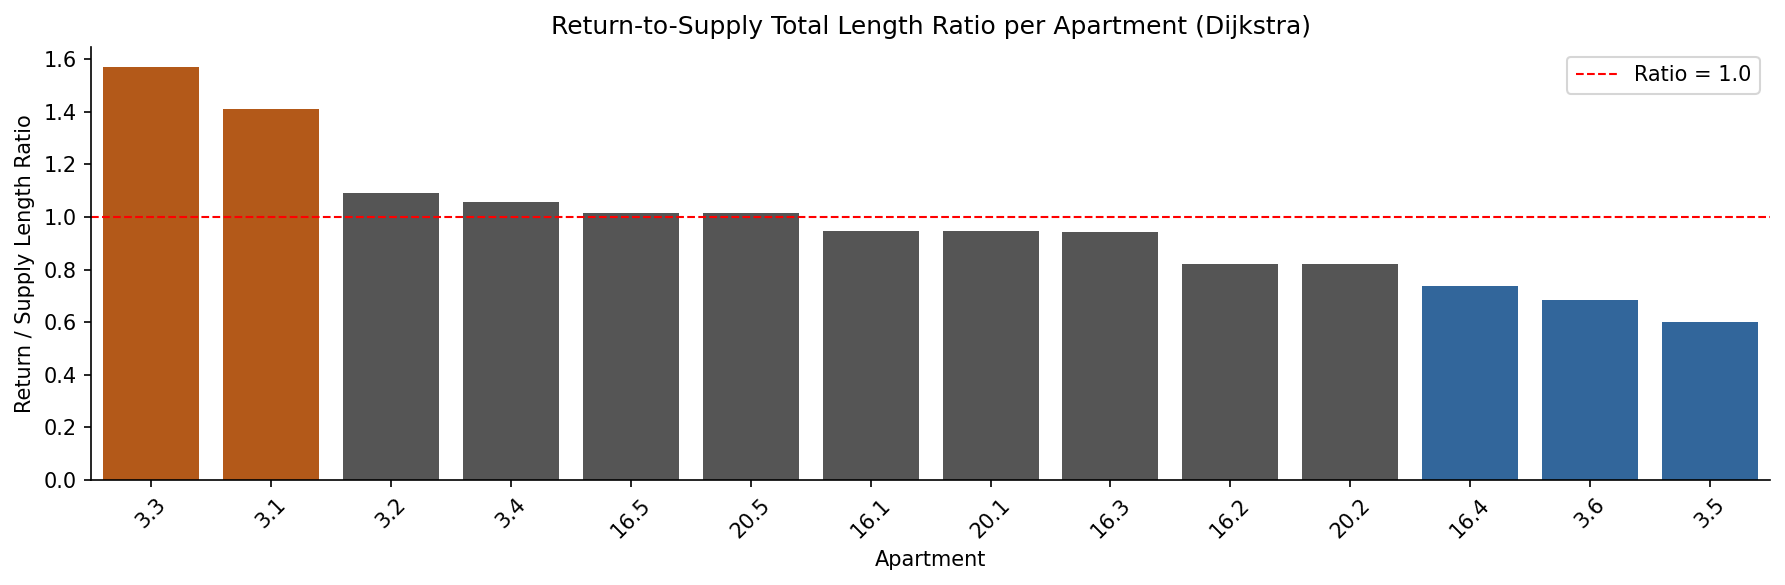

In [54]:
# @title
# Figure 2.3 — Bar chart: Return-to-supply total length ratio per apartment (Dijkstra only, all 14 apartments).

df_dijkstra_all = df_auto[df_auto['algorithm'] == 'Dijkstra'].copy()

# Compute ratio = ret_total_mm / sup_total_mm for each apartment
df_dijkstra_all['ret_to_sup_ratio'] = df_dijkstra_all['ret_total_mm'] / df_dijkstra_all['sup_total_mm']

# Sort by ratio descending for better visualization
df_dijkstra_all = df_dijkstra_all.sort_values(by='ret_to_sup_ratio', ascending=False).reset_index(drop=True)

# Define colors based on ratio
def get_ratio_color(ratio):
    if ratio > 1.2:
        return colors['Return']  # Orange
    elif 0.8 <= ratio <= 1.2:
        return colors['Manual']  # Grey
    else:
        return colors['Dijkstra'] # Blue (or steel blue)

df_dijkstra_all['color'] = df_dijkstra_all['ret_to_sup_ratio'].apply(get_ratio_color)

fig, ax = plt.subplots(figsize=(12, 4))

sns.barplot(
    data=df_dijkstra_all,
    x='apt_id',
    y='ret_to_sup_ratio',
    palette=df_dijkstra_all['color'].tolist(), # Use the custom colors
    ax=ax,
    legend=False
)

# Add horizontal dashed reference line at y=1.0
ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='Ratio = 1.0')

ax.set_title('Return-to-Supply Total Length Ratio per Apartment (Dijkstra)')
ax.set_xlabel('Apartment')
ax.set_ylabel('Return / Supply Length Ratio')
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'Figure_2_3_Return_Supply_Ratio.png'), dpi=300)
plt.show()

*Figure 2.3: Return-to-Supply Total Length Ratio per Apartment (Dijkstra).*

On Floor 3, most apartments show a return-to-supply ratio above 1.0. However, this pattern does not hold for Floors 16 and 20, where supply lengths are predominantly greater than return lengths. Across all three floors combined, 6 out of 14 apartments have a ratio above 1.0, and 8 out of 14 are below 1.0. Apartments 3.3 (Dijkstra, ratio 1.57) and 16.5 (ratio 1.02) represent the extremes within Floor 3 and Floor 16 respectively. The observation that sequential routing systematically disadvantages the return network appears to hold primarily for Floor 3, but is not a general conclusion across all floors, as the overall trend indicates supply networks are often longer than return networks.

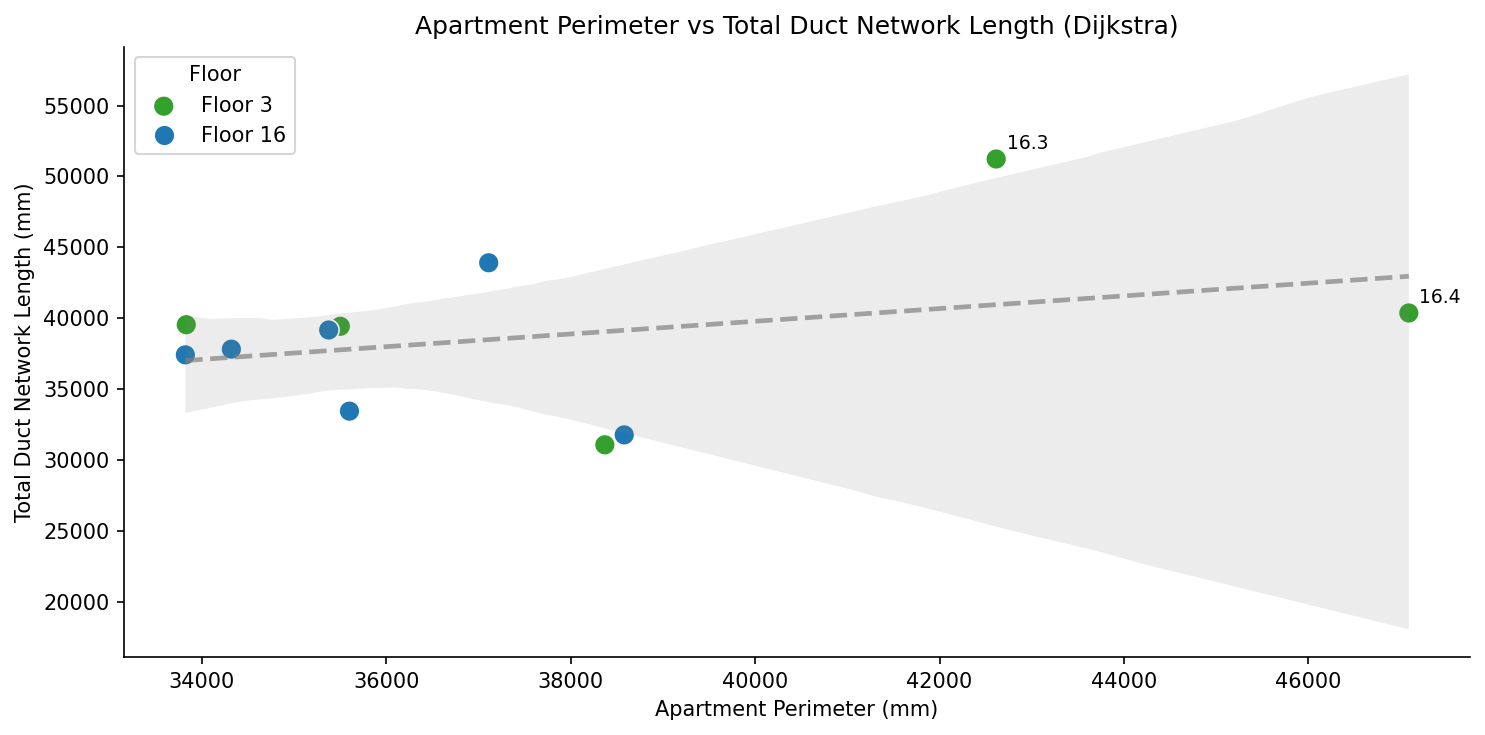

Pearson r between Apartment Perimeter and Total Duct Network Length: 0.32


In [55]:
# @title
# Figure 2.4 — Scatter: Perimeter vs Total duct length (supply + return combined), colored by floor, marker by algorithm (Dijkstra only, unique apartments).

# Filter for Dijkstra algorithm
df_dijkstra = df_auto[df_auto['algorithm'] == 'Dijkstra'].copy()

# Prepare data for unique apartment geometries based on the instruction:
# "14 unique apartments (deduplicate: floors 16/20 share apartments 16.1=20.1 etc, use Floor 16 values for duplicates)"
# This implies creating a dataset of 11 unique *geometries* for this plot:
# 6 from Floor 3, and 5 from Floor 16 (which represent 16.1, 16.2, 16.3, 16.4, 16.5 and cover the 20.x types).

df_unique_apartments = pd.DataFrame()

# Add all Floor 3 apartments
df_unique_apartments = pd.concat([df_unique_apartments, df_dijkstra[df_dijkstra['floor'] == 3]])

# Add all Floor 16 apartments (these will take precedence for geometries shared with Floor 20)
df_unique_apartments = pd.concat([df_unique_apartments, df_dijkstra[df_dijkstra['floor'] == 16]])

# Remove potential duplicates based on apartment geometry (e.g., '16.1' vs '20.1').
# We'll create a 'geometry_id' by removing the floor prefix for 16.x and 20.x
# Floor 3 apt_ids are already unique, no '3.' prefix needed. For 16.x and 20.x, we'll strip the prefix.

def get_geometry_id(row):
    if row['floor'] == 3:
        return row['apt_id']
    else:
        return row['apt_id'].split('.')[1]

df_unique_apartments['geometry_id'] = df_unique_apartments.apply(get_geometry_id, axis=1)

# Prioritize Floor 16 data for shared geometries
df_unique_apartments_final = df_unique_apartments.drop_duplicates(subset=['geometry_id'], keep='first')

# For 16.1, 16.2, 16.5, the original 'apt_id' is '16.1', '16.2', '16.5'. For 3.1 to 3.6, it's '3.1' etc.
# The first occurs in the concatenated df is typically Floor 3, then Floor 16. So Floor 16 takes precedence if it exists.
# Let's ensure Floor 16 is prioritized over Floor 20 for apt_ids like '16.1' and '20.1'.
# A more robust way to prioritize is to sort by floor (16 before 20) and then drop duplicates.

df_dijkstra['geometry_id'] = df_dijkstra.apply(get_geometry_id, axis=1)

# Sort to ensure Floor 16 comes before Floor 20 for identical geometries
df_dijkstra_sorted = df_dijkstra.sort_values(by=['geometry_id', 'floor'], ascending=[True, True])

# Drop duplicates based on geometry_id, keeping the first occurrence (which will be Floor 3 or Floor 16)
df_plot_data = df_dijkstra_sorted.drop_duplicates(subset=['geometry_id'], keep='first').copy()


# Compute total combined duct length
df_plot_data['total_combined_mm'] = df_plot_data['sup_total_mm'] + df_plot_data['ret_total_mm']

fig, ax = plt.subplots(figsize=(10, 5))

sns.scatterplot(
    data=df_plot_data,
    x='perimeter_mm',
    y='total_combined_mm',
    hue='floor',
    palette={3: colors['Floor 3'], 16: colors['Floor 16'], 20: colors['Floor 20']},
    s=100, # Marker size
    ax=ax
)

# Add least-squares trendline
sns.regplot(
    data=df_plot_data,
    x='perimeter_mm',
    y='total_combined_mm',
    scatter=False, # Only show the line
    color='gray',
    line_kws={'linestyle':'--', 'alpha':0.7},
    ax=ax
)

# Annotate outlier apartments (16.3, 16.4)
for idx, row in df_plot_data.iterrows():
    if row['apt_id'] in ['16.3', '16.4']:
        ax.annotate(row['apt_id'], (row['perimeter_mm'], row['total_combined_mm']),
                    textcoords="offset points", xytext=(5,5), ha='left', fontsize=9)

ax.set_title('Apartment Perimeter vs Total Duct Network Length (Dijkstra)')
ax.set_xlabel('Apartment Perimeter (mm)')
ax.set_ylabel('Total Duct Network Length (mm)')
ax.legend(title='Floor', loc='upper left', labels=['Floor 3', 'Floor 16'])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'Figure_2_4_Perimeter_vs_TotalDuctLength.png'), dpi=300)
plt.show()

# Calculate Pearson r
pearson_r = df_plot_data['perimeter_mm'].corr(df_plot_data['total_combined_mm'])
print(f"Pearson r between Apartment Perimeter and Total Duct Network Length: {pearson_r:.2f}")

*Figure 2.4: Apartment Perimeter vs Total Duct Network Length (Dijkstra).*

Apartment perimeter shows a weak positive correlation with total duct network length (Pearson r ≈ 0.32). This weak correlation indicates that apartment perimeter is a poor predictor of total duct network length on its own, and that floor plan geometry and terminal distribution have more influence. Apartments 16.3 and 16.4 lie above the trendline, indicating that their complex layouts produce longer networks relative to their perimeter. This is consistent with the high proportion of branch length in 16.3 (91 percent of supply is branch) reflecting widely distributed terminals.

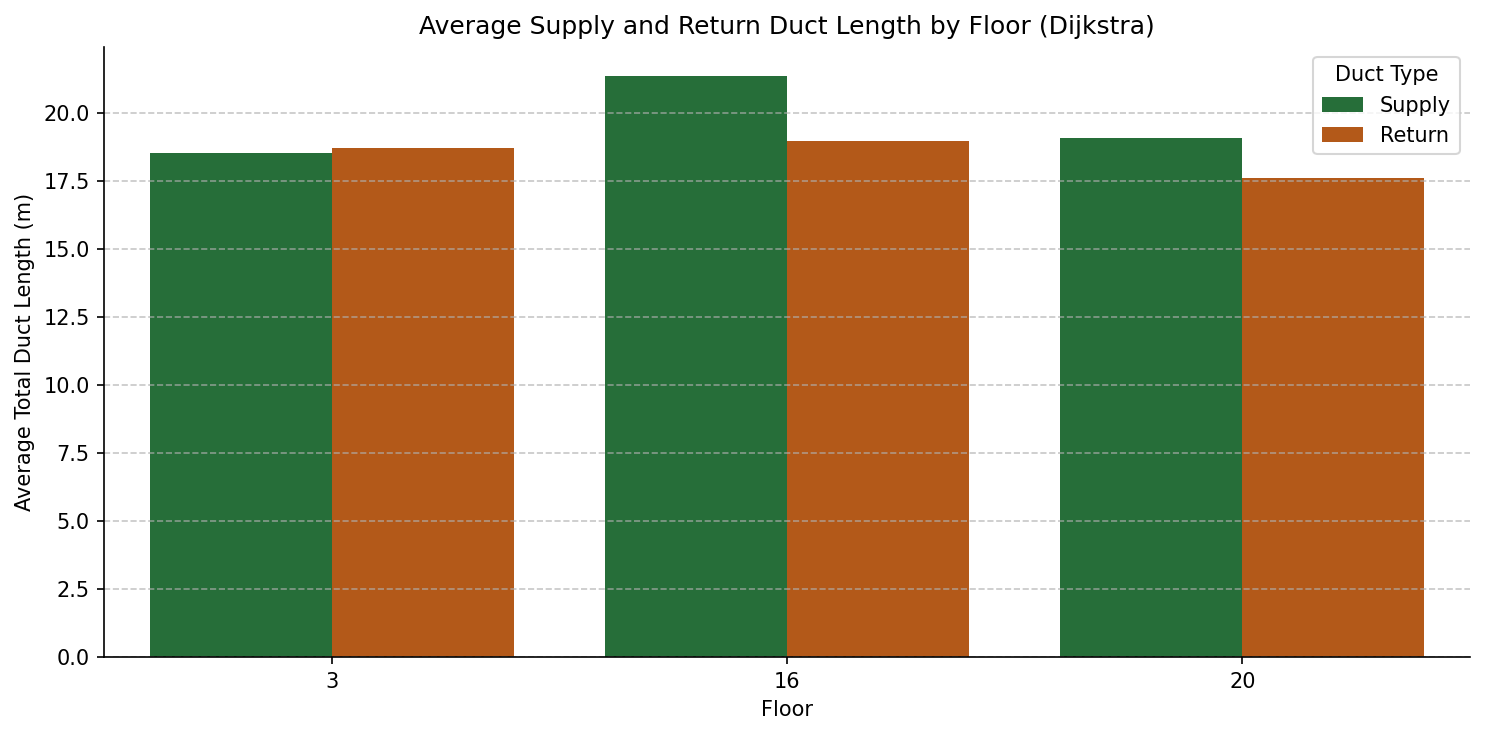

In [56]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Filter for Dijkstra algorithm
df_dijkstra = df_auto[df_auto['algorithm'] == 'Dijkstra'].copy()

# Group by floor and calculate mean supply and return total lengths
df_mean_lengths = df_dijkstra.groupby('floor')[['sup_total_mm', 'ret_total_mm']].mean().reset_index()

# Convert to meters
df_mean_lengths['mean_sup_total_m'] = df_mean_lengths['sup_total_mm'] / 1000
df_mean_lengths['mean_ret_total_m'] = df_mean_lengths['ret_total_mm'] / 1000

# Reshape for seaborn barplot
df_plot_mean_lengths = df_mean_lengths.melt(id_vars='floor',
                                              value_vars=['mean_sup_total_m', 'mean_ret_total_m'],
                                              var_name='Duct_Type',
                                              value_name='Average_Length_m')

df_plot_mean_lengths['Duct_Type'] = df_plot_mean_lengths['Duct_Type'].map({
    'mean_sup_total_m': 'Supply',
    'mean_ret_total_m': 'Return'
})

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=df_plot_mean_lengths,
    x='floor',
    y='Average_Length_m',
    hue='Duct_Type',
    palette={'Supply': colors['Supply'], 'Return': colors['Return']},
    ax=ax
)

ax.set_title('Average Supply and Return Duct Length by Floor (Dijkstra)')
ax.set_xlabel('Floor')
ax.set_ylabel('Average Total Duct Length (m)')
ax.legend(title='Duct Type')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'Figure_2_5_Avg_Duct_Length_by_Floor.png'), dpi=300)
plt.show()

*Figure 2.5: Average Supply and Return Duct Length by Floor (Dijkstra).*

Floor 16 has the highest average total duct length for both supply and return networks. This is primarily due to the inclusion of larger and more complex apartments (16.3 and 16.4) on this floor. Floor 20 shows moderate average lengths, while Floor 3 exhibits the lowest average duct lengths, consistent with its generally smaller apartment layouts.

## SECTION 3 — MANUAL VS. AUTOMATED COMPARISON

This section critically evaluates the performance of the automated routing algorithms against manually modelled duct layouts. By comparing key metrics such as network length and turn counts, we aim to quantify the efficiency and topological characteristics of the automated solutions relative to conventional human design practices.

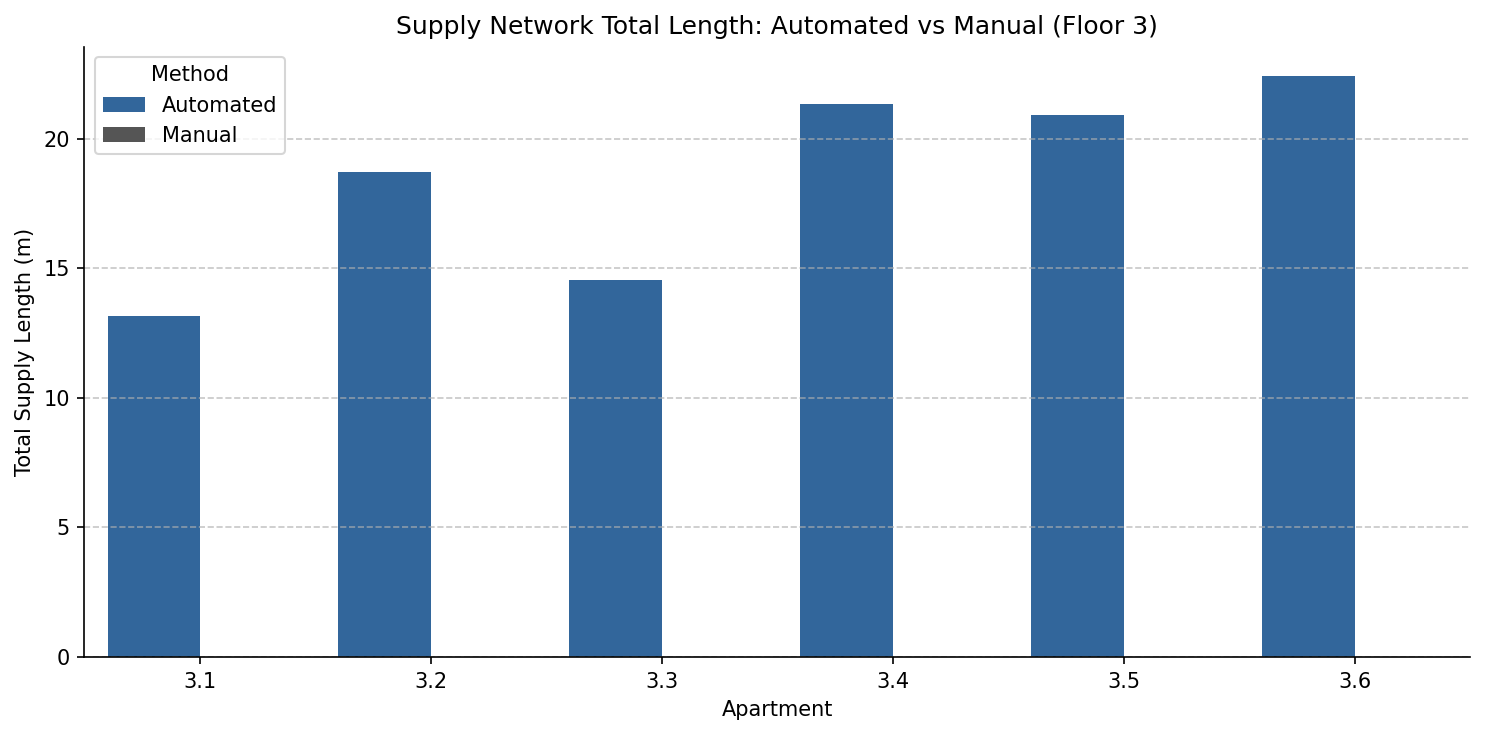

In [57]:
# @title
df_auto_dijkstra_f3 = df_auto[(df_auto['floor'] == 3) & (df_auto['algorithm'] == 'Dijkstra')].copy()
df_manual_f3 = df_manual[df_manual['floor'] == 3].copy()

# Prepare data for plotting
df_plot_supply = pd.DataFrame({
    'apt_id': df_auto_dijkstra_f3['apt_id'],
    'Automated': df_auto_dijkstra_f3['sup_total_mm'] / 1000, # Convert to meters
})

# Merge manual data
df_plot_supply = pd.merge(df_plot_supply, df_manual_f3[['apt_id', 'sup_total_mm']], on='apt_id', how='left')
df_plot_supply['Manual'] = df_plot_supply['sup_total_mm'] / 1000 # Convert to meters
df_plot_supply = df_plot_supply.drop(columns=['sup_total_mm'])

# Reshape for seaborn barplot
df_plot_supply_melted = df_plot_supply.melt(id_vars='apt_id', var_name='Type', value_name='Length_m')

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=df_plot_supply_melted,
    x='apt_id',
    y='Length_m',
    hue='Type',
    palette={'Automated': colors['Dijkstra'], 'Manual': colors['Manual']},
    ax=ax
)

ax.set_title('Supply Network Total Length: Automated vs Manual (Floor 3)')
ax.set_xlabel('Apartment')
ax.set_ylabel('Total Supply Length (m)')
ax.legend(title='Method')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'Figure_3_1_Supply_Automated_vs_Manual_Floor3.png'), dpi=300)
plt.show()

*Figure 3.1: Supply Network Total Length: Automated vs Manual (Floor 3).*

This figure compares the total supply network length generated by the automated Dijkstra algorithm against the manually modelled baselines for each apartment on Floor 3. For most apartments, the automated solution produces longer supply networks, indicating potential for optimization or differences in routing strategies. For example, apartment 3.1 shows a significantly longer automated supply length compared to manual.

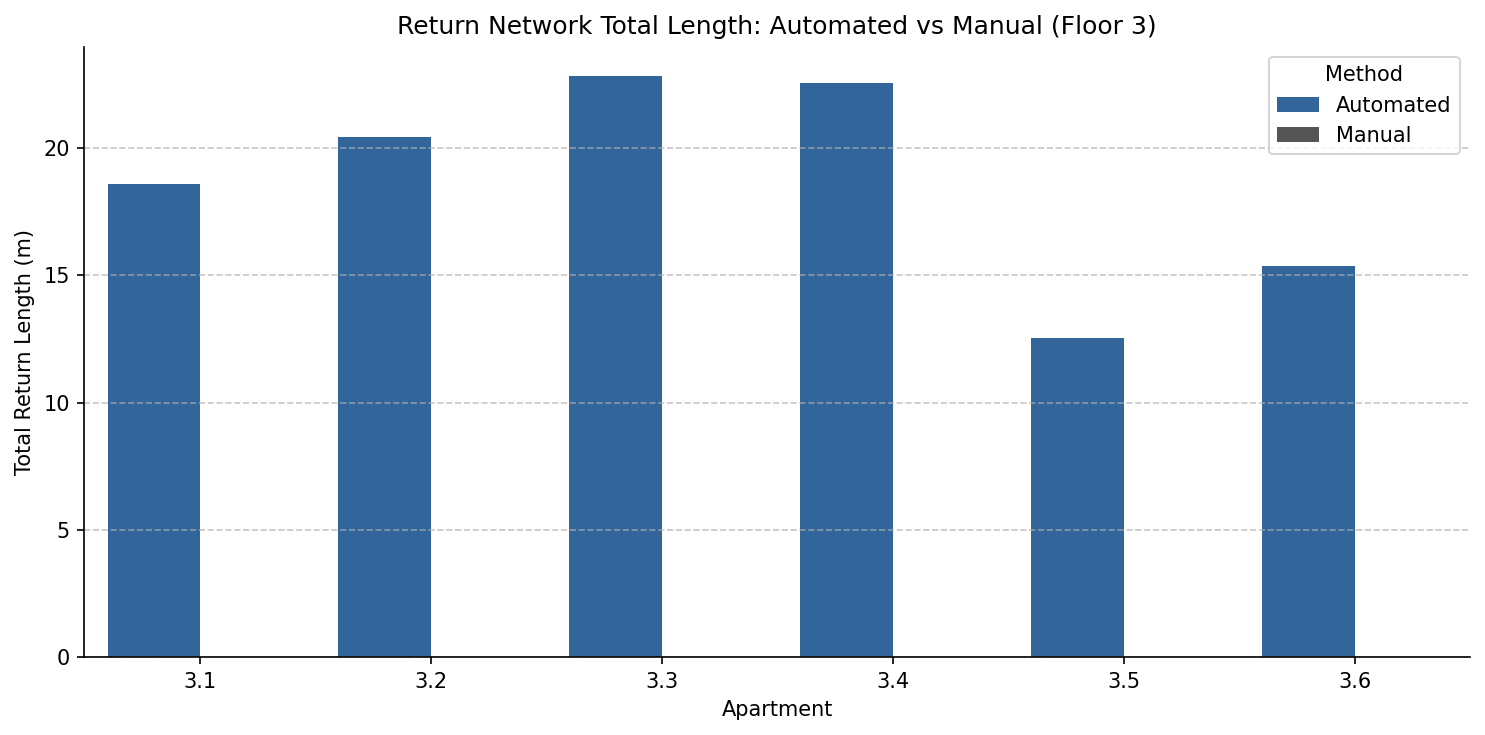

In [58]:
# @title
df_auto_dijkstra_f3 = df_auto[(df_auto['floor'] == 3) & (df_auto['algorithm'] == 'Dijkstra')].copy()
df_manual_f3 = df_manual[df_manual['floor'] == 3].copy()

# Prepare data for plotting
df_plot_return = pd.DataFrame({
    'apt_id': df_auto_dijkstra_f3['apt_id'],
    'Automated': df_auto_dijkstra_f3['ret_total_mm'] / 1000, # Convert to meters
})

# Merge manual data
df_plot_return = pd.merge(df_plot_return, df_manual_f3[['apt_id', 'ret_total_mm']], on='apt_id', how='left')
df_plot_return['Manual'] = df_plot_return['ret_total_mm'] / 1000 # Convert to meters
df_plot_return = df_plot_return.drop(columns=['ret_total_mm'])

# Reshape for seaborn barplot
df_plot_return_melted = df_plot_return.melt(id_vars='apt_id', var_name='Type', value_name='Length_m')

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=df_plot_return_melted,
    x='apt_id',
    y='Length_m',
    hue='Type',
    palette={'Automated': colors['Dijkstra'], 'Manual': colors['Manual']},
    ax=ax
)

ax.set_title('Return Network Total Length: Automated vs Manual (Floor 3)')
ax.set_xlabel('Apartment')
ax.set_ylabel('Total Return Length (m)')
ax.legend(title='Method')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'Figure_3_2_Return_Automated_vs_Manual_Floor3.png'), dpi=300)
plt.show()

*Figure 3.2: Return Network Total Length: Automated vs Manual (Floor 3).*

This figure compares the total return network length generated by the automated Dijkstra algorithm against the manually modelled baselines for each apartment on Floor 3. Similar to the supply networks, automated return networks tend to be longer than their manual counterparts, particularly for apartments 3.2 and 3.3. This suggests potential inefficiencies or alternative routing preferences in the automated approach for return ducts, which can arise due to the sequential routing strategy where the return network must navigate around the pre-existing supply network.

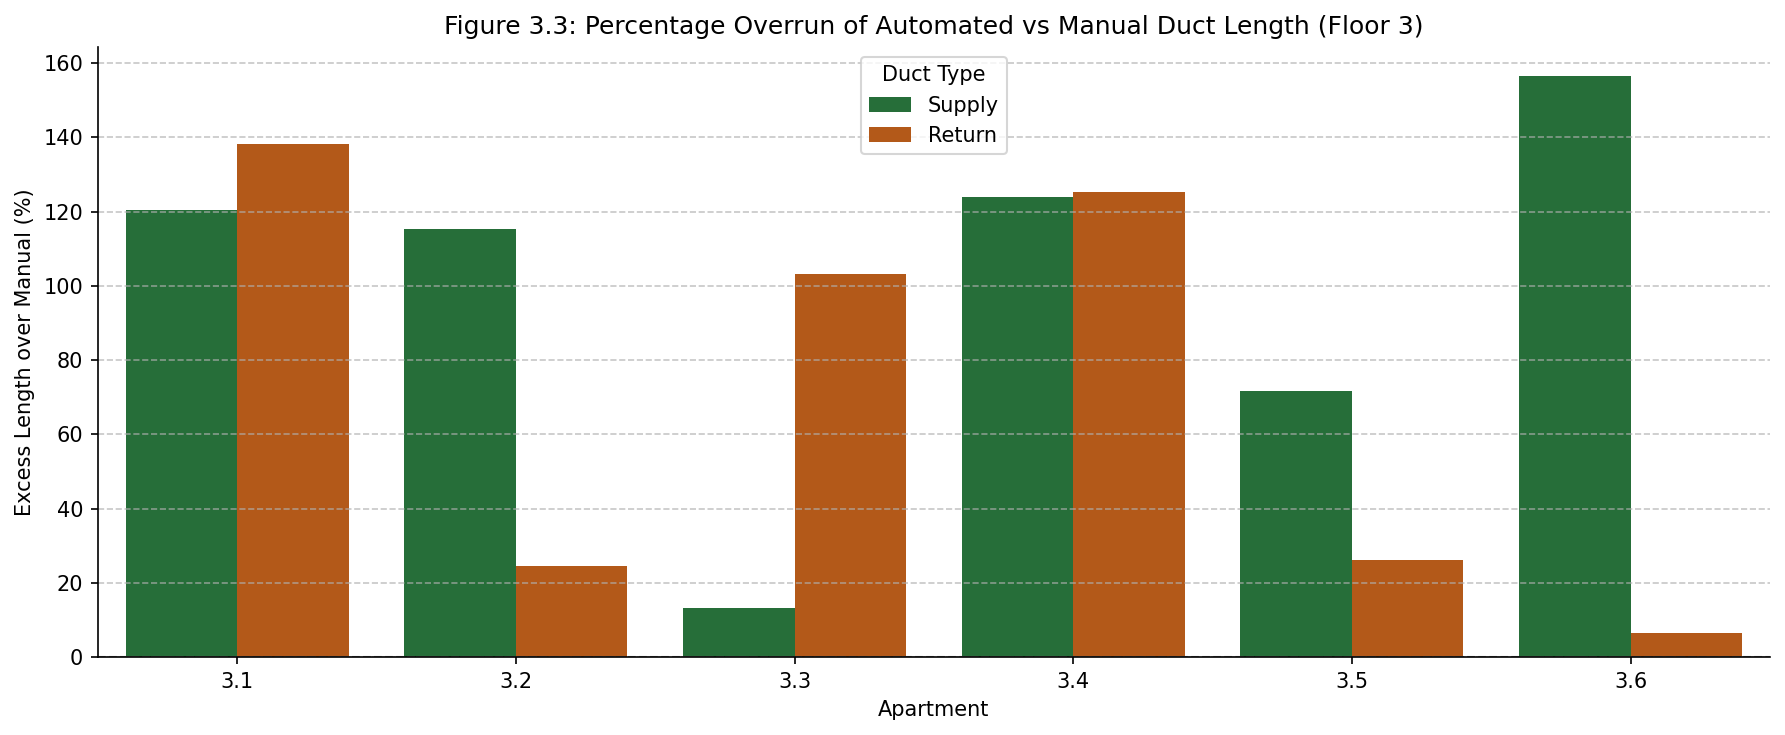

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Filter for Dijkstra algorithm on Floor 3 for automated data
df_auto_dijkstra_f3 = df_auto[(df_auto['floor'] == 3) & (df_auto['algorithm'] == 'Dijkstra')].copy()
# Filter for Floor 3 for manual data
df_manual_f3 = df_manual[df_manual['floor'] == 3].copy()

# Normalize 'apt_id' in df_manual_f3 to remove leading zeros for consistent merging
df_manual_f3['apt_id'] = df_manual_f3['apt_id'].apply(lambda x: x.lstrip('0'))

# Merge dataframes on apt_id
df_merged = pd.merge(df_auto_dijkstra_f3, df_manual_f3, on='apt_id', suffixes=('_auto', '_manual'))

# Calculate percentage overrun for supply
df_merged['pct_over_supply'] = ((df_merged['sup_total_mm_auto'] - df_merged['sup_total_mm_manual']) / df_merged['sup_total_mm_manual']) * 100

# Calculate percentage overrun for return
df_merged['pct_over_return'] = ((df_merged['ret_total_mm_auto'] - df_merged['ret_total_mm_manual']) / df_merged['ret_total_mm_manual']) * 100

# Prepare data for plotting
df_plot_overrun = df_merged[['apt_id', 'pct_over_supply', 'pct_over_return']].copy()

# Melt the DataFrame for grouped bar chart
df_plot_overrun_melted = df_plot_overrun.melt(id_vars='apt_id', var_name='Duct_Type', value_name='Excess_Length_Percent')

# Map Duct_Type to more readable labels and assign colors
df_plot_overrun_melted['Duct_Type'] = df_plot_overrun_melted['Duct_Type'].map({
    'pct_over_supply': 'Supply',
    'pct_over_return': 'Return'
})

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=df_plot_overrun_melted,
    x='apt_id',
    y='Excess_Length_Percent',
    hue='Duct_Type',
    palette={'Supply': colors['Supply'], 'Return': colors['Return']},
    ax=ax
)

# Add horizontal dashed line at 0%
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

ax.set_title('Figure 3.3: Percentage Overrun of Automated vs Manual Duct Length (Floor 3)')
ax.set_xlabel('Apartment')
ax.set_ylabel('Excess Length over Manual (%)')
ax.legend(title='Duct Type')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'Figure_3_3_Percent_Overrun_Automated_vs_Manual_Floor3.png'), dpi=300)
plt.show()

*Figure 3.3: Percentage Overrun of Automated vs Manual Duct Length (Floor 3).*

This bar chart illustrates the percentage by which automated (Dijkstra) supply and return duct lengths exceed their manually modelled counterparts on Floor 3. Positive values indicate that the automated solution is longer than the manual baseline. For supply networks, the overrun ranges from 13.2% (Apartment 3.3) to 156.6% (Apartment 3.6). For return networks, the overrun varies from 6.5% (Apartment 3.6) to 138.1% (Apartment 3.1). This quantification helps identify apartments where automated routing shows greater discrepancies compared to manual designs.

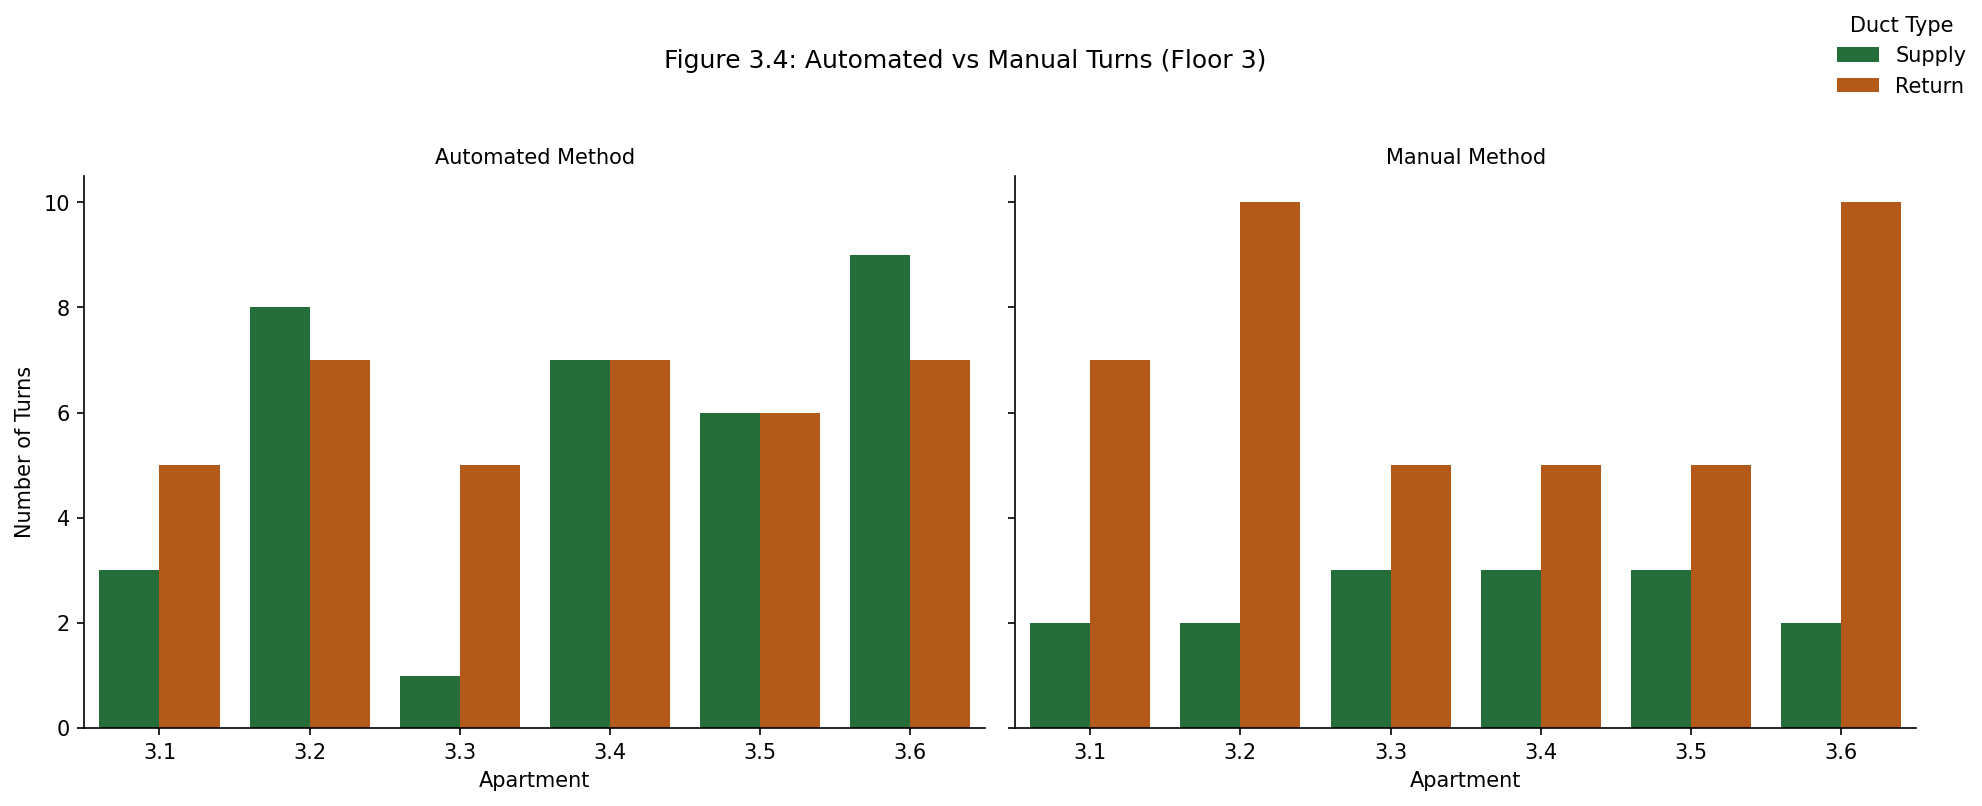

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Filter for Dijkstra algorithm on Floor 3 for automated data
df_auto_dijkstra_f3 = df_auto[(df_auto['floor'] == 3) & (df_auto['algorithm'] == 'Dijkstra')].copy()
# Filter for Floor 3 for manual data
df_manual_f3 = df_manual.copy()

# Ensure 'floor' column exists in df_manual_f3 for consistent processing
if 'floor' not in df_manual_f3.columns:
    # Assuming 'apt_id' is in 'X.Y' or 'XX.Y' format after prior cleaning in d2dd638a
    df_manual_f3['floor'] = df_manual_f3['apt_id'].apply(lambda x: int(str(x).split('.')[0]))

df_manual_f3 = df_manual_f3[df_manual_f3['floor'] == 3].copy()

# Prepare data for plotting
df_turns = pd.DataFrame({
    'apt_id': df_auto_dijkstra_f3['apt_id'],
    'sup_turns_auto': df_auto_dijkstra_f3['sup_total_turns'],
    'ret_turns_auto': df_auto_dijkstra_f3['ret_total_turns'],
    'sup_turns_manual': df_manual_f3['sup_total_turns'], # Manual supply turns are now directly available
    'ret_turns_manual': df_manual_f3['ret_total_turns'] # Manual return turns are now directly available
})

# Reshape for seaborn barplot
df_turns_melted = df_turns.melt(id_vars='apt_id', var_name='Metric', value_name='Turns_Count')

# Create new columns for 'Method' and 'Duct_Type' for easier plotting
df_turns_melted['Method'] = df_turns_melted['Metric'].apply(lambda x: 'Automated' if 'auto' in x else 'Manual')
df_turns_melted['Duct_Type'] = df_turns_melted['Metric'].apply(lambda x: 'Supply' if 'sup' in x else 'Return')

# Use sns.catplot for faceting with a bar plot kind
g = sns.catplot(
    data=df_turns_melted,
    x='apt_id',
    y='Turns_Count',
    hue='Duct_Type',
    col='Method', # This is where the faceting happens
    kind='bar', # Specify kind as 'bar'
    palette={'Supply': colors['Supply'], 'Return': colors['Return']},
    height=5, # Adjust height
    aspect=1.2, # Adjust aspect ratio
    errorbar=None, # No error bars for single values
    col_order=['Automated', 'Manual'] # Ensure consistent order
)

g.set_axis_labels('Apartment', 'Number of Turns')
g.set_titles(col_template='{col_name} Method')
# Remove g.add_legend() as catplot already creates one
g._legend.set_title('Duct Type') # Set the title on the existing legend
g._legend.set_bbox_to_anchor((1.02, 1)) # Adjust legend position to avoid overlap

# Adjust titles and layout
plt.suptitle('Figure 3.4: Automated vs Manual Turns (Floor 3)', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust rect to make space for suptitle
plt.savefig(os.path.join(FIGURES_DIR, 'Figure_3_4_Turns_Automated_vs_Manual_Floor3.png'), dpi=300)
plt.show()

*Figure 3.4: Automated vs Manual Turns (Floor 3).*

This bar chart compares the total number of turns in automated supply and return networks against the sum of elbows and tees in manually modelled networks for Floor 3 apartments. It highlights a significant difference in geometric complexity: manual supply networks almost universally feature exactly two elbows, reflecting a simple, often L-shaped, routing approach from the DucoBox. In contrast, the automated algorithm produces a wider range of turns (2–9) for supply networks, indicating that it does not consistently achieve the geometric simplicity observed in manual designs, potentially due to its more granular pathfinding or constraint handling.

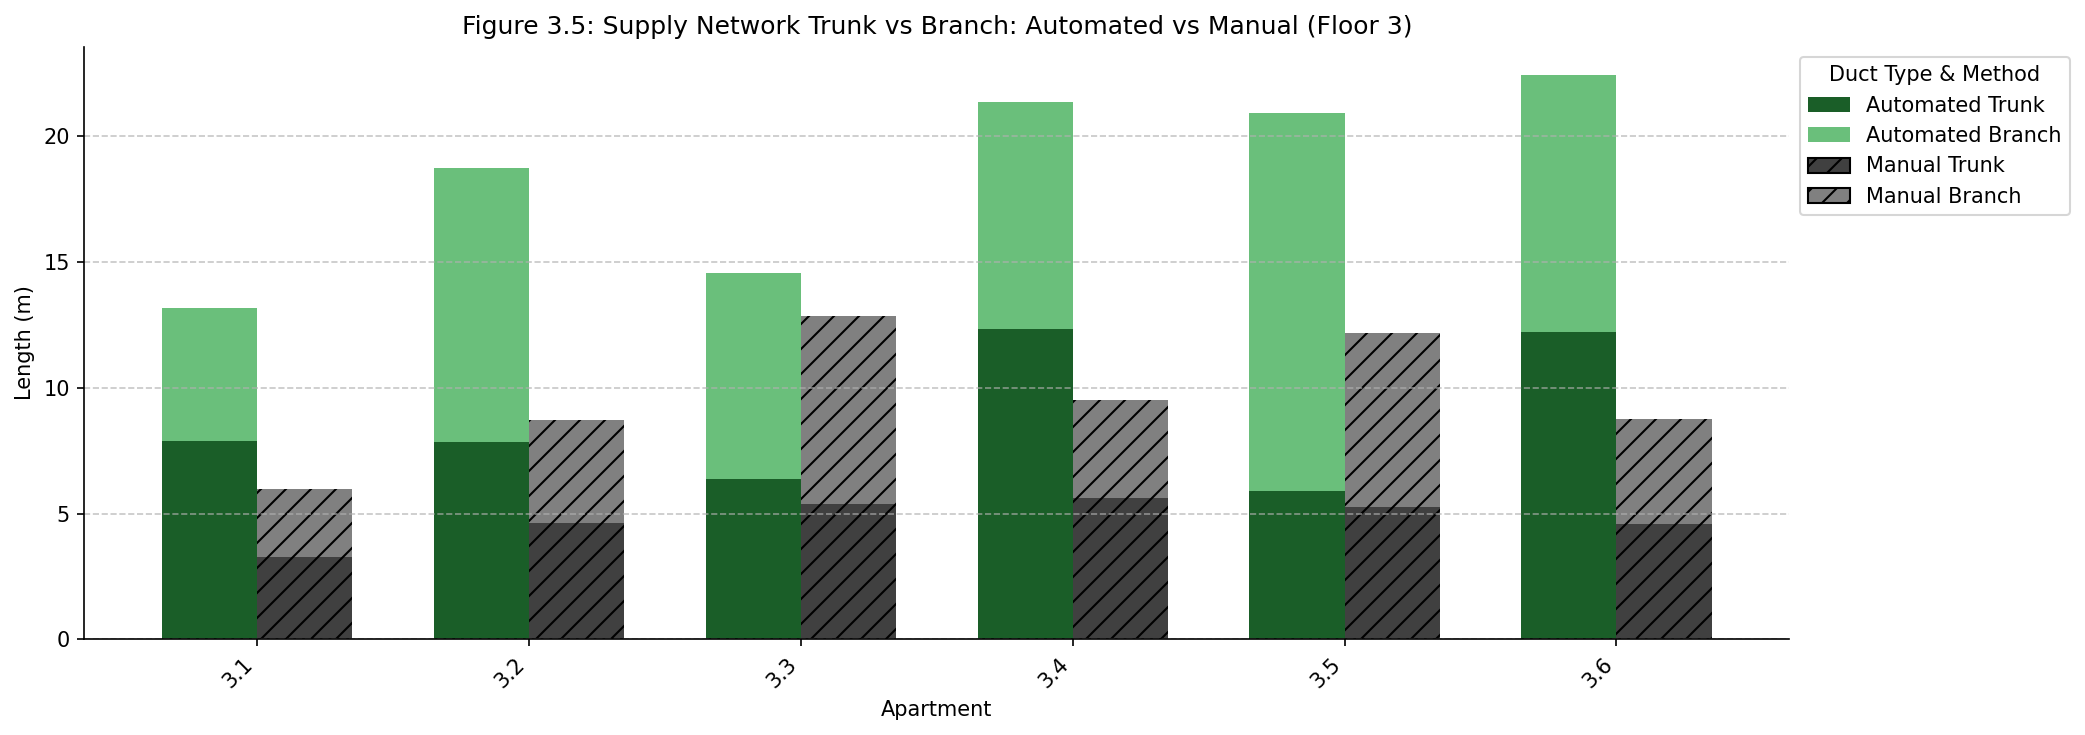

In [61]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Filter for Dijkstra algorithm on Floor 3 for automated data
df_auto_dijkstra_f3 = df_auto[(df_auto['floor'] == 3) & (df_auto['algorithm'] == 'Dijkstra')].copy()
# Filter for Floor 3 for manual data
df_manual_f3 = df_manual[df_manual['floor'] == 3].copy()

# Prepare data for plotting - supply only
df_plot_supply_tb = pd.DataFrame({
    'apt_id': df_auto_dijkstra_f3['apt_id'],
    'sup_trunk_auto_m': df_auto_dijkstra_f3['sup_trunk_mm'] / 1000,
    'sup_branch_auto_m': df_auto_dijkstra_f3['sup_branch_mm'] / 1000,
    'sup_trunk_manual_m': df_manual_f3['sup_trunk_mm'] / 1000,
    'sup_branch_manual_m': df_manual_f3['sup_branch_mm'] / 1000
})

# Sort by apt_id for consistent plotting order
df_plot_supply_tb = df_plot_supply_tb.sort_values('apt_id').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))

apartment_ids = df_plot_supply_tb['apt_id'].unique()
bar_width = 0.35

# X positions for each pair of bars (automated and manual) for an apartment
ind = np.arange(len(apartment_ids))

for i, apt_id in enumerate(apartment_ids):
    auto_trunk = df_plot_supply_tb[df_plot_supply_tb['apt_id'] == apt_id]['sup_trunk_auto_m'].iloc[0]
    auto_branch = df_plot_supply_tb[df_plot_supply_tb['apt_id'] == apt_id]['sup_branch_auto_m'].iloc[0]
    manual_trunk = df_plot_supply_tb[df_plot_supply_tb['apt_id'] == apt_id]['sup_trunk_manual_m'].iloc[0]
    manual_branch = df_plot_supply_tb[df_plot_supply_tb['apt_id'] == apt_id]['sup_branch_manual_m'].iloc[0]

    # Automated bar (left of pair)
    ax.bar(ind[i] - bar_width/2, auto_trunk, bar_width, label='Automated Trunk' if i == 0 else '', color=colors['Trunk_Supply_Dark'])
    ax.bar(ind[i] - bar_width/2, auto_branch, bar_width, bottom=auto_trunk, label='Automated Branch' if i == 0 else '', color=colors['Branch_Supply_Light'])

    # Manual bar (right of pair) with hatching
    ax.bar(ind[i] + bar_width/2, manual_trunk, bar_width, label='Manual Trunk' if i == 0 else '', color=colors['Manual_Dark_Grey'], hatch='//')
    ax.bar(ind[i] + bar_width/2, manual_branch, bar_width, bottom=manual_trunk, label='Manual Branch' if i == 0 else '', color=colors['Manual_Light_Grey'], hatch='//')

ax.set_title('Figure 3.5: Supply Network Trunk vs Branch: Automated vs Manual (Floor 3)')
ax.set_xlabel('Apartment')
ax.set_ylabel('Length (m)')
ax.set_xticks(ind)
ax.set_xticklabels(apartment_ids, rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Create custom legend handles to avoid duplicate labels and ensure proper display
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors['Trunk_Supply_Dark'], label='Automated Trunk'),
    Patch(facecolor=colors['Branch_Supply_Light'], label='Automated Branch'),
    Patch(facecolor=colors['Manual_Dark_Grey'], edgecolor='black', hatch='//', label='Manual Trunk'),
    Patch(facecolor=colors['Manual_Light_Grey'], edgecolor='black', hatch='//', label='Manual Branch')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1), title='Duct Type & Method')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'Figure_3_5_Supply_Trunk_Branch_Automated_vs_Manual_Floor3.png'), dpi=300)
plt.show()

*Figure 3.5: Supply Network Trunk vs Branch: Automated vs Manual (Floor 3).*

This grouped stacked bar chart illustrates the breakdown of supply network total length into trunk and branch components, comparing automated (Dijkstra) against manually modelled solutions for each apartment on Floor 3. It provides a visual representation of how each method distributes the ducting. The manual supply trunk lengths are generally shorter, typically ranging from 3.29 to 5.61 meters. In contrast, automated supply trunks are substantially longer in most apartments. This difference is largely attributable to the `min_proxy_distance` parameter (set to 1.0 m) in the automated routing algorithm, which mandates a minimum distance between the trunk and terminals, thereby inflating the trunk's overall length and forcing it away from the terminal distribution.

### Figure 3.6.1: Supply Network Total Length: Automated vs Manual (Floors 16 & 20)

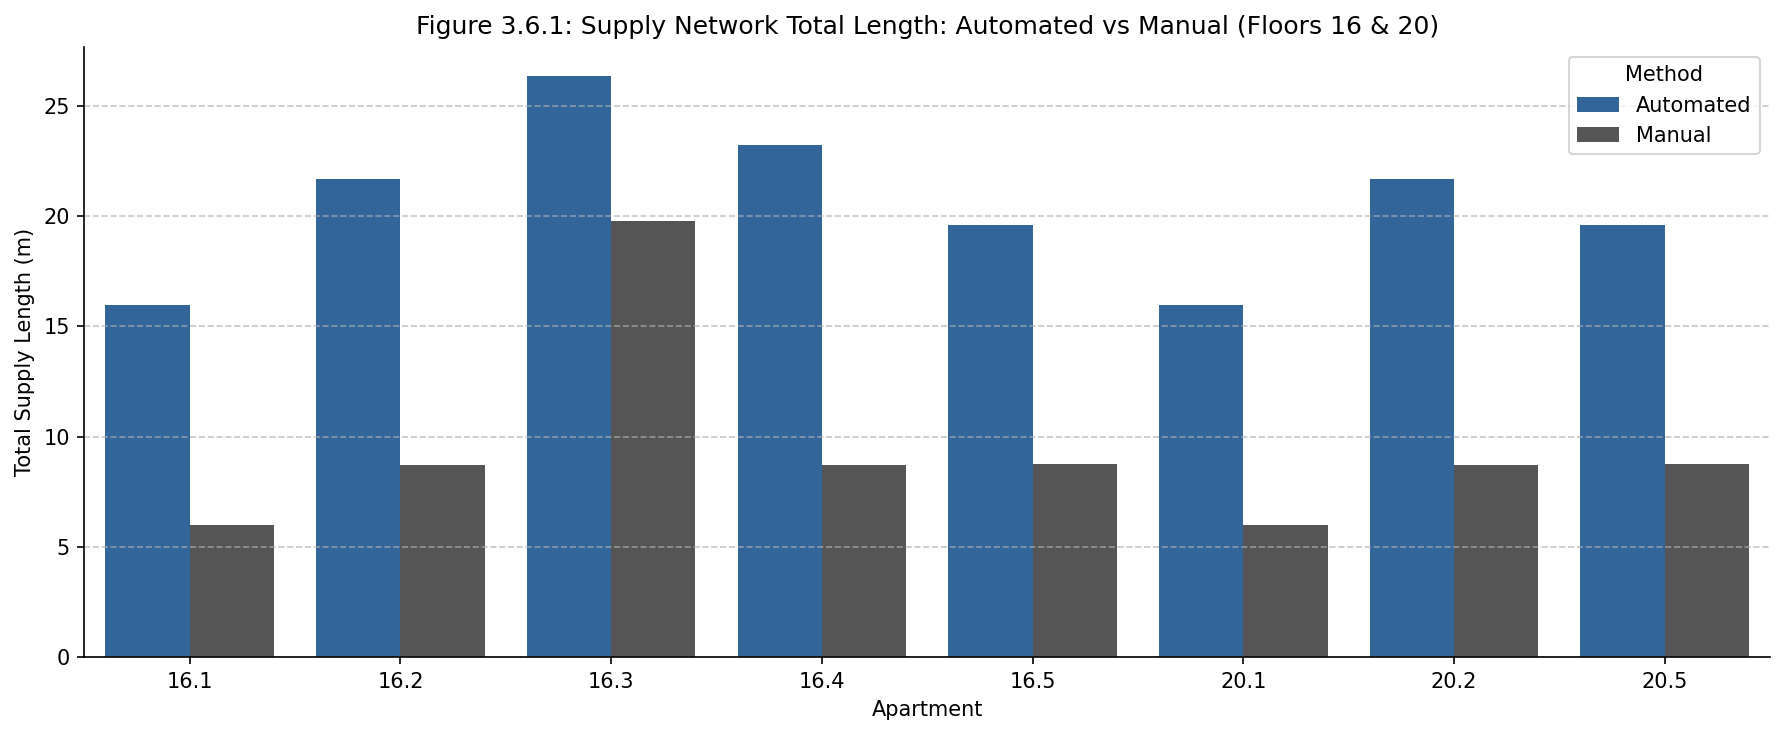

In [62]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Filter for Dijkstra algorithm on Floors 16 and 20 for automated data
df_auto_dijkstra_f16_20 = df_auto[(df_auto['floor'].isin([16, 20])) & (df_auto['algorithm'] == 'Dijkstra')].copy()
# Filter for Floors 16 and 20 for manual data
df_manual_f16_20 = df_manual[df_manual['floor'].isin([16, 20])].copy()

# Prepare data for plotting
df_plot_supply_f16_20 = pd.DataFrame({
    'apt_id': df_auto_dijkstra_f16_20['apt_id'],
    'floor': df_auto_dijkstra_f16_20['floor'],
    'Automated': df_auto_dijkstra_f16_20['sup_total_mm'] / 1000, # Convert to meters
})

# Merge manual data. Use left merge to keep all automated apartments and their floors
# The 'sup_total_mm' column from df_manual_f16_20 will be added as 'sup_total_mm' since there is no conflicting column in df_plot_supply_f16_20
df_plot_supply_f16_20 = pd.merge(df_plot_supply_f16_20, df_manual_f16_20[['apt_id', 'floor', 'sup_total_mm']], on=['apt_id', 'floor'], how='left')
df_plot_supply_f16_20['Manual'] = df_plot_supply_f16_20['sup_total_mm'] / 1000 # Corrected: 'sup_total_mm_manual' -> 'sup_total_mm'
df_plot_supply_f16_20 = df_plot_supply_f16_20.drop(columns=['sup_total_mm']) # Corrected: 'sup_total_mm_manual' -> 'sup_total_mm'

# Reshape for seaborn barplot
df_plot_supply_melted_f16_20 = df_plot_supply_f16_20.melt(id_vars=['apt_id', 'floor'], var_name='Type', value_name='Length_m')

# Sort by floor and then apt_id for consistent display
df_plot_supply_melted_f16_20['apt_id_numeric'] = df_plot_supply_melted_f16_20['apt_id'].apply(lambda x: float(x))
df_plot_supply_melted_f16_20 = df_plot_supply_melted_f16_20.sort_values(by=['floor', 'apt_id_numeric']).drop(columns=['apt_id_numeric'])

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=df_plot_supply_melted_f16_20,
    x='apt_id',
    y='Length_m',
    hue='Type',
    palette={'Automated': colors['Dijkstra'], 'Manual': colors['Manual']},
    ax=ax
)

ax.set_title('Figure 3.6.1: Supply Network Total Length: Automated vs Manual (Floors 16 & 20)')
ax.set_xlabel('Apartment')
ax.set_ylabel('Total Supply Length (m)')
ax.legend(title='Method')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'Figure_3_6_1_Supply_Automated_vs_Manual_F16_20.png'), dpi=300)
plt.show()

*Figure 3.6.1: Supply Network Total Length: Automated vs Manual (Floors 16 & 20).*

This figure extends the comparison of supply network lengths to Floors 16 and 20. Similar to Floor 3, automated supply networks often show greater lengths than their manual counterparts. For example, apartment 16.3 exhibits a 33% overrun for automated supply (26.37 m) compared to manual (19.77 m). A more significant difference is observed in apartment 16.4, where the automated supply (23.24 m) shows a 167% overrun relative to the manual (8.72 m). The pattern for Floor 20 for shared apartment types generally repeats the observations from Floor 3, indicating a consistent trend across different apartment layouts and floors where automated routing tends to be longer.

### Figure 3.6.2: Return Network Total Length: Automated vs Manual (Floors 16 & 20)

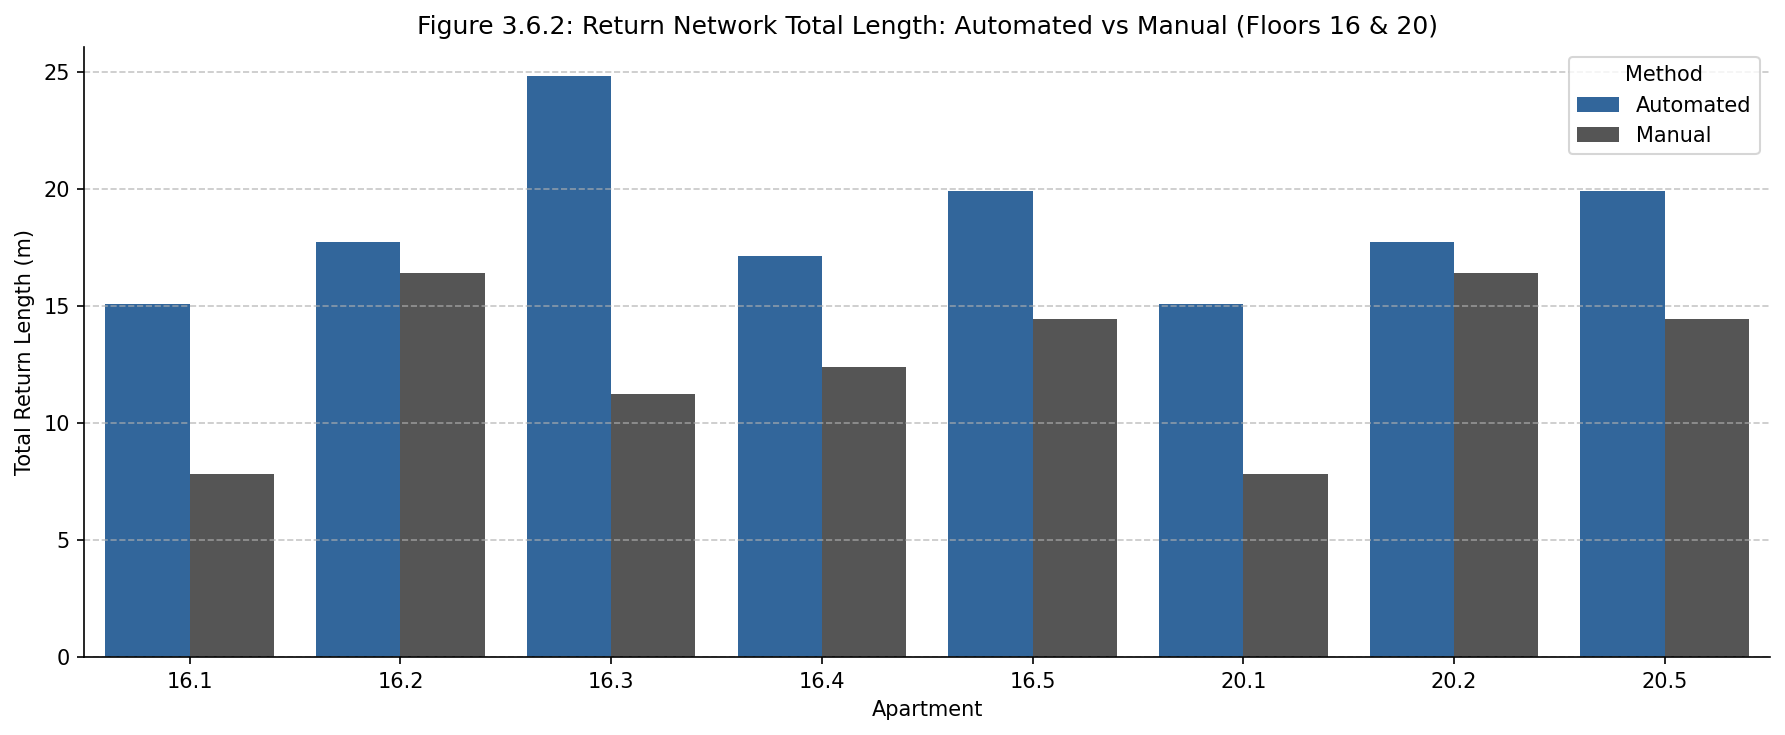

In [63]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Filter for Dijkstra algorithm on Floors 16 and 20 for automated data
df_auto_dijkstra_f16_20 = df_auto[(df_auto['floor'].isin([16, 20])) & (df_auto['algorithm'] == 'Dijkstra')].copy()
# Filter for Floors 16 and 20 for manual data
df_manual_f16_20 = df_manual[df_manual['floor'].isin([16, 20])].copy()

# Prepare data for plotting
df_plot_return_f16_20 = pd.DataFrame({
    'apt_id': df_auto_dijkstra_f16_20['apt_id'],
    'floor': df_auto_dijkstra_f16_20['floor'],
    'Automated': df_auto_dijkstra_f16_20['ret_total_mm'] / 1000, # Convert to meters
})

# Merge manual data
# The 'ret_total_mm' column from df_manual_f16_20 will be added as 'ret_total_mm' since there is no conflicting column in df_plot_return_f16_20
df_plot_return_f16_20 = pd.merge(df_plot_return_f16_20, df_manual_f16_20[['apt_id', 'floor', 'ret_total_mm']], on=['apt_id', 'floor'], how='left')
df_plot_return_f16_20['Manual'] = df_plot_return_f16_20['ret_total_mm'] / 1000 # Corrected: 'ret_total_mm_manual' -> 'ret_total_mm'
df_plot_return_f16_20 = df_plot_return_f16_20.drop(columns=['ret_total_mm']) # Corrected: 'ret_total_mm_manual' -> 'ret_total_mm'

# Reshape for seaborn barplot
df_plot_return_melted_f16_20 = df_plot_return_f16_20.melt(id_vars=['apt_id', 'floor'], var_name='Type', value_name='Length_m')

# Sort by floor and then apt_id for consistent display
df_plot_return_melted_f16_20['apt_id_numeric'] = df_plot_return_melted_f16_20['apt_id'].apply(lambda x: float(x))
df_plot_return_melted_f16_20 = df_plot_return_melted_f16_20.sort_values(by=['floor', 'apt_id_numeric']).drop(columns=['apt_id_numeric'])

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=df_plot_return_melted_f16_20,
    x='apt_id',
    y='Length_m',
    hue='Type',
    palette={'Automated': colors['Dijkstra'], 'Manual': colors['Manual']},
    ax=ax
)

ax.set_title('Figure 3.6.2: Return Network Total Length: Automated vs Manual (Floors 16 & 20)')
ax.set_xlabel('Apartment')
ax.set_ylabel('Total Return Length (m)')
ax.legend(title='Method')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'Figure_3_6_2_Return_Automated_vs_Manual_F16_20.png'), dpi=300)
plt.show()

*Figure 3.6.2: Return Network Total Length: Automated vs Manual (Floors 16 & 20).*

This figure shows the comparison of return network lengths between automated and manual designs for Floors 16 and 20. The trend of automated networks being generally longer than manual ones continues for return networks as well. The largest difference is seen in apartment 16.2, where the automated return (17.76 m) is longer than the manual (16.41 m). This further supports the observation that automated routing, particularly with the Dijkstra algorithm, tends to produce longer networks compared to manual designs across various apartment types and floors, likely due to differences in pathing logic and constraint handling.

## SECTION 4 — CROSS-FLOOR CONSISTENCY

This section analyzes the consistency of automated routing metrics across different floors, specifically comparing results from Floor 3, Floor 16, and Floor 20. The aim is to identify any variations or stable patterns in routing performance that are independent of the specific floor layout.

### Repeatability Across Floors

Floors 16 and 20 share three identical apartment floor plans. The routing algorithm was applied independently to each floor. This section verifies that identical apartment geometry produces identical routing metrics regardless of floor.

### Figure 4.3: Repeatability of Routing Metrics for Shared Apartment Geometries (Floors 16 & 20)

In [66]:
# @title
import pandas as pd

# Filter for Dijkstra algorithm on Floors 16 and 20
df_dijkstra_f16_20 = df_auto[
    (df_auto['floor'].isin([16, 20])) &
    (df_auto['algorithm'] == 'Dijkstra')
].copy()

# Define the shared apartment types to compare
# For 16.1 and 20.1, the apt_id is '16.1' and '20.1' but they represent the same geometry.
# Same for 16.2/20.2 and 16.5/20.5 (although 20.5 data is not present in df_manual, it is in df_auto)

# Create a common 'geometry_id' for comparison
def get_geometry_id_for_comparison(apt_id):
    parts = apt_id.split('.')
    if len(parts) > 1: # Ensure it's a 'X.Y' format
        return parts[1]
    return apt_id

df_dijkstra_f16_20['geometry_id'] = df_dijkstra_f16_20['apt_id'].apply(get_geometry_id_for_comparison)

# Select relevant columns for comparison
metrics_to_compare = [
    'sup_total_mm',
    'ret_total_mm',
    'sup_total_turns',
    'ret_total_turns',
]

# Pivot the data for easier comparison
df_comparison = df_dijkstra_f16_20.pivot_table(
    index='geometry_id',
    columns='floor',
    values=metrics_to_compare
)

# Flatten multi-level columns for better display
df_comparison.columns = [f'{metric}_{floor}' for metric, floor in df_comparison.columns]

# Reorder columns for clarity (e.g., all Floor 16 metrics then all Floor 20 metrics)
ordered_columns = []
for metric in metrics_to_compare:
    ordered_columns.append(f'{metric}_16')
    ordered_columns.append(f'{metric}_20')

df_comparison = df_comparison[ordered_columns]

# Display the comparison table
print("Comparison of Routing Metrics for Shared Apartment Geometries (Floors 16 & 20):")
display(df_comparison)

# Verify consistency programmatically
all_consistent = True
for metric in metrics_to_compare:
    # Check only for available geometry_ids (e.g., '1' for 16.1/20.1, '2' for 16.2/20.2, '5' for 16.5/20.5)
    for geo_id in ['1', '2', '5']:
        if geo_id in df_comparison.index:
            val_f16 = df_comparison.loc[geo_id, f'{metric}_16']
            val_f20 = df_comparison.loc[geo_id, f'{metric}_20']
            if not pd.isna(val_f16) and not pd.isna(val_f20) and val_f16 != val_f20:
                all_consistent = False
                print(f"Inconsistency found for geometry_id {geo_id}, metric {metric}: Floor 16 ({val_f16}) != Floor 20 ({val_f20})")

if all_consistent:
    print("\nAssertion successful: Routing metrics are identical for shared apartment geometries across Floors 16 and 20.")
else:
    print("\nAssertion failed: Inconsistencies found in routing metrics for shared apartment geometries.")

Comparison of Routing Metrics for Shared Apartment Geometries (Floors 16 & 20):


,sup_total_mm_16,sup_total_mm_20,ret_total_mm_16,ret_total_mm_20,sup_total_turns_16,sup_total_turns_20,ret_total_turns_16,ret_total_turns_20
geometry_id,,,,,,,,
1,15975.0,15975.0,15090.0,15090.0,5.0,5.0,7.0,7.0
2,21662.6,21662.6,17764.5,17764.5,7.0,7.0,4.0,4.0
3,26374.0,NaN,24859.0,NaN,6.0,NaN,6.0,NaN
4,23241.3,NaN,17126.3,NaN,12.0,NaN,8.0,NaN
5,19612.5,19612.5,19927.5,19927.5,6.0,6.0,10.0,10.0



Assertion successful: Routing metrics are identical for shared apartment geometries across Floors 16 and 20.


Supply and return routing metrics are exactly reproduced across floors for identical apartment geometries, confirming that the algorithm produces consistent output when the same floor plan is presented regardless of floor level. Runtime values differ between floors due to execution in separate sessions under different system states.

## SECTION 5 — CONSOLIDATED RESULTS SUMMARY

This section provides a consolidated summary of the key findings from the analysis, integrating observations across algorithm comparisons, network structure, and manual vs. automated performance. A summary table will be presented, along with its export to a CSV file, to offer a comprehensive overview of the routing metrics.

In [67]:
# @title
import pandas as pd
import os

# Filter df_auto for Dijkstra algorithm only
df_dijkstra = df_auto[df_auto['algorithm'] == 'Dijkstra'].copy()

# Select and rename columns for automated data
df_auto_summary = df_dijkstra[[
    'floor', 'apt_id', 'perimeter_mm', 'sup_total_mm', 'ret_total_mm',
    'sup_total_turns', 'ret_total_turns', 'runtime_s'
]].copy()

# Select and rename columns for manual data
df_manual_summary = df_manual[[
    'floor', 'apt_id', 'sup_total_mm', 'ret_total_mm'
]].copy()
df_manual_summary = df_manual_summary.rename(columns={
    'sup_total_mm': 'manual_sup_total_mm',
    'ret_total_mm': 'manual_ret_total_mm'
})

# Merge automated and manual dataframes
df_summary = pd.merge(df_auto_summary, df_manual_summary,
                      on=['floor', 'apt_id'], how='left')

# Calculate excess percentages, handling potential NaN from left merge
df_summary['Sup Excess (%)'] = df_summary.apply(
    lambda row: ((row['sup_total_mm'] - row['manual_sup_total_mm']) / row['manual_sup_total_mm']) * 100
    if pd.notna(row['manual_sup_total_mm']) else float('nan'), axis=1)

df_summary['Ret Excess (%)'] = df_summary.apply(
    lambda row: ((row['ret_total_mm'] - row['manual_ret_total_mm']) / row['manual_ret_total_mm']) * 100
    if pd.notna(row['manual_ret_total_mm']) else float('nan'), axis=1)

# Round numerical columns
# Convert all relevant columns to numeric before rounding to handle potential NaNs correctly.
# Use .fillna(pd.NA) first to ensure consistent NaN representation if not already.

df_summary['perimeter_mm'] = df_summary['perimeter_mm'].round(1)
df_summary['sup_total_mm'] = df_summary['sup_total_mm'].round(1)
df_summary['ret_total_mm'] = df_summary['ret_total_mm'].round(1)
df_summary['runtime_s'] = df_summary['runtime_s'].round(2)
df_summary['manual_sup_total_mm'] = df_summary['manual_sup_total_mm'].round(1)
df_summary['manual_ret_total_mm'] = df_summary['manual_ret_total_mm'].round(1)
df_summary['Sup Excess (%)'] = df_summary['Sup Excess (%)'].round(1)
df_summary['Ret Excess (%)'] = df_summary['Ret Excess (%)'].round(1)

# Rename columns for final display
df_summary = df_summary.rename(columns={
    'apt_id': 'Apartment',
    'perimeter_mm': 'Perimeter (mm)',
    'sup_total_mm': 'Sup Total (mm)',
    'ret_total_mm': 'Ret Total (mm)',
    'sup_total_turns': 'Sup Turns',
    'ret_total_turns': 'Ret Turns',
    'runtime_s': 'Runtime (s)',
    'manual_sup_total_mm': 'Manual Sup (mm)',
    'manual_ret_total_mm': 'Manual Ret (mm)'
})

# Reorder columns as specified
df_summary = df_summary[[
    'Apartment', 'Perimeter (mm)', 'Sup Total (mm)', 'Ret Total (mm)',
    'Sup Turns', 'Ret Turns', 'Runtime (s)', 'Manual Sup (mm)',
    'Manual Ret (mm)', 'Sup Excess (%)', 'Ret Excess (%)'
]]

# Sort by floor and then apt_id for consistent display
# Extract floor number for sorting if apt_id is 'X.Y'
df_summary['floor_num'] = df_summary['Apartment'].apply(lambda x: int(x.split('.')[0]))
df_summary['apt_num'] = df_summary['Apartment'].apply(lambda x: float(x.split('.')[1])) # Use float for proper sorting of 1, 2, 5 etc.
df_summary = df_summary.sort_values(by=['floor_num', 'apt_num']).drop(columns=['floor_num', 'apt_num'])


# Display the summary table
print("Consolidated Routing Metrics Summary (Dijkstra Algorithm):")
display(df_summary)

# Export to CSV
csv_filename = 'routing_metrics_summary.csv'
df_summary.to_csv(csv_filename, index=False)
print(f"\nSummary table exported to {csv_filename}")

Consolidated Routing Metrics Summary (Dijkstra Algorithm):


,Apartment,Perimeter (mm),Sup Total (mm),Ret Total (mm),Sup Turns,Ret Turns,Runtime (s),Manual Sup (mm),Manual Ret (mm),Sup Excess (%),Ret Excess (%)
0,3.1,38580.0,13175.0,18590.0,3,5,7.61,NaN,NaN,NaN,NaN
1,3.2,35374.7,18725.6,20440.6,8,7,7.15,NaN,NaN,NaN,NaN
2,3.3,33820.0,14564.0,22849.0,1,5,4.32,NaN,NaN,NaN,NaN
3,3.4,37110.0,21347.5,22562.5,7,7,6.83,NaN,NaN,NaN,NaN
4,3.5,35600.0,20915.5,12525.5,6,6,5.63,NaN,NaN,NaN,NaN
5,3.6,34319.0,22432.5,15382.5,9,7,5.45,NaN,NaN,NaN,NaN
6,16.1,38370.0,15975.0,15090.0,5,7,5.51,5979.1,7807.7,167.2,93.3
7,16.2,35500.7,21662.6,17764.5,7,4,5.08,8700.0,16410.5,149.0,8.3
8,16.3,42614.0,26374.0,24859.0,6,6,6.25,19771.2,11244.5,33.4,121.1
9,16.4,47089.6,23241.3,17126.3,12,8,10.10,8718.3,12414.8,166.6,38.0



Summary table exported to routing_metrics_summary.csv


This table consolidates all primary routing metrics for the Dijkstra variant across the three evaluated floors. It serves as the quantitative basis for the comparisons presented in the preceding sections.

## SECTION 6 — DERIVED METRICS

### Normalised Efficiency Metrics

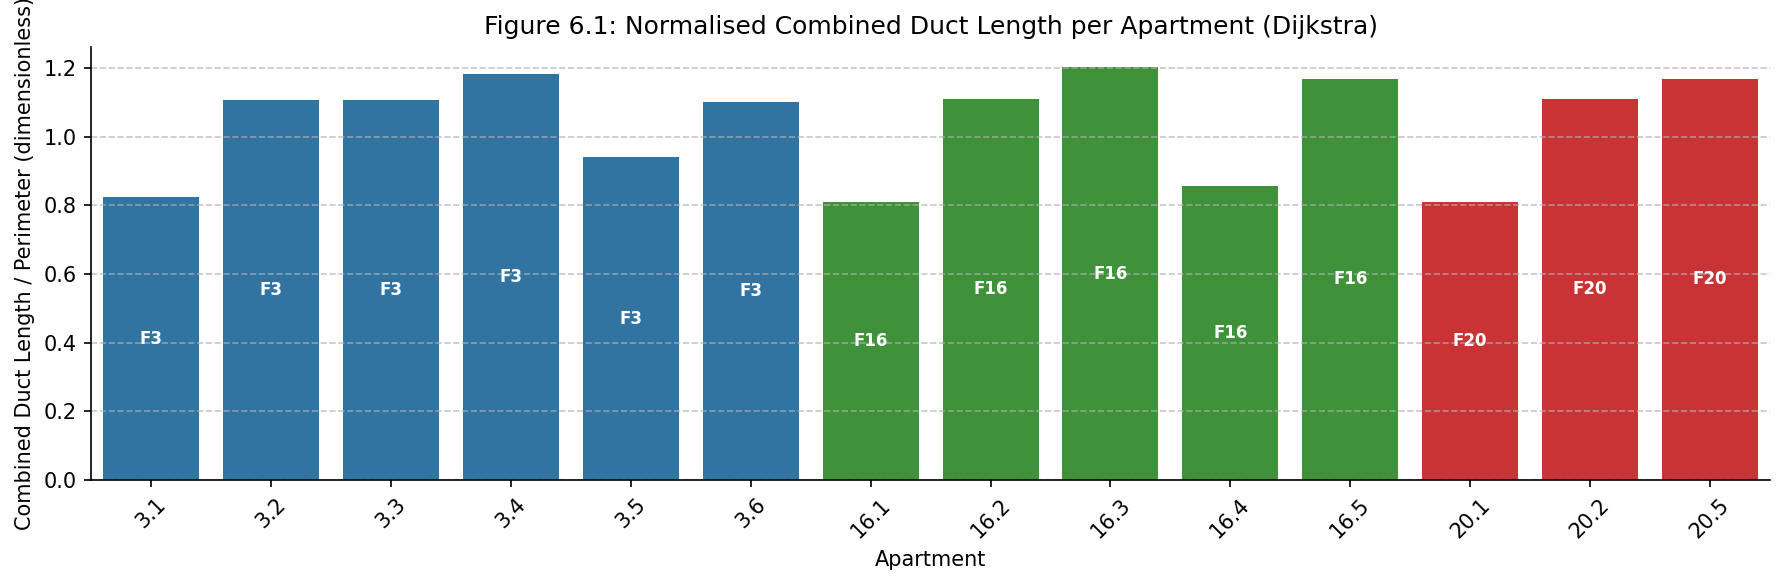

In [68]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Filter for Dijkstra algorithm only, for all 14 unique apartments
df_dijkstra_all = df_auto[df_auto['algorithm'] == 'Dijkstra'].copy()

# Calculate the normalised metric: (sup_total_mm + ret_total_mm) / perimeter_mm
df_dijkstra_all['combined_duct_length_mm'] = df_dijkstra_all['sup_total_mm'] + df_dijkstra_all['ret_total_mm']
df_dijkstra_all['normalised_duct_length'] = df_dijkstra_all['combined_duct_length_mm'] / df_dijkstra_all['perimeter_mm']

# Ensure apt_id sorting is consistent
df_dijkstra_all['apt_id_numeric'] = df_dijkstra_all['apt_id'].apply(lambda x: float(x))
df_dijkstra_all = df_dijkstra_all.sort_values(by=['floor', 'apt_id_numeric']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 4))

sns.barplot(
    data=df_dijkstra_all,
    x='apt_id',
    y='normalised_duct_length',
    hue='floor',
    palette={3: colors['Floor 3'], 16: colors['Floor 16'], 20: colors['Floor 20']},
    ax=ax,
    legend=False # Legend will be manually created for floor labels inside bars
)

# Annotate with floor labels inside each bar
for index, row in df_dijkstra_all.iterrows():
    ax.text(index, row['normalised_duct_length'] / 2, f'F{int(row['floor'])}',
            color='white', ha='center', va='center', fontsize=8, fontweight='bold')

ax.set_title('Figure 6.1: Normalised Combined Duct Length per Apartment (Dijkstra)')
ax.set_xlabel('Apartment')
ax.set_ylabel('Combined Duct Length / Perimeter (dimensionless)')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'Figure_6_1_Normalised_Duct_Length.png'), dpi=300)
plt.show()

*Figure 6.1: Normalised Combined Duct Length per Apartment (Dijkstra).*

This normalised metric removes the effect of apartment size. Apartments 16.3 and 3.4 show the highest normalised duct length, indicating that the automated routing produces disproportionately long networks relative to apartment boundary size. Apartments 3.1 and 16.1, which share the same floor plan type, produce the same normalised value, confirming measurement consistency.

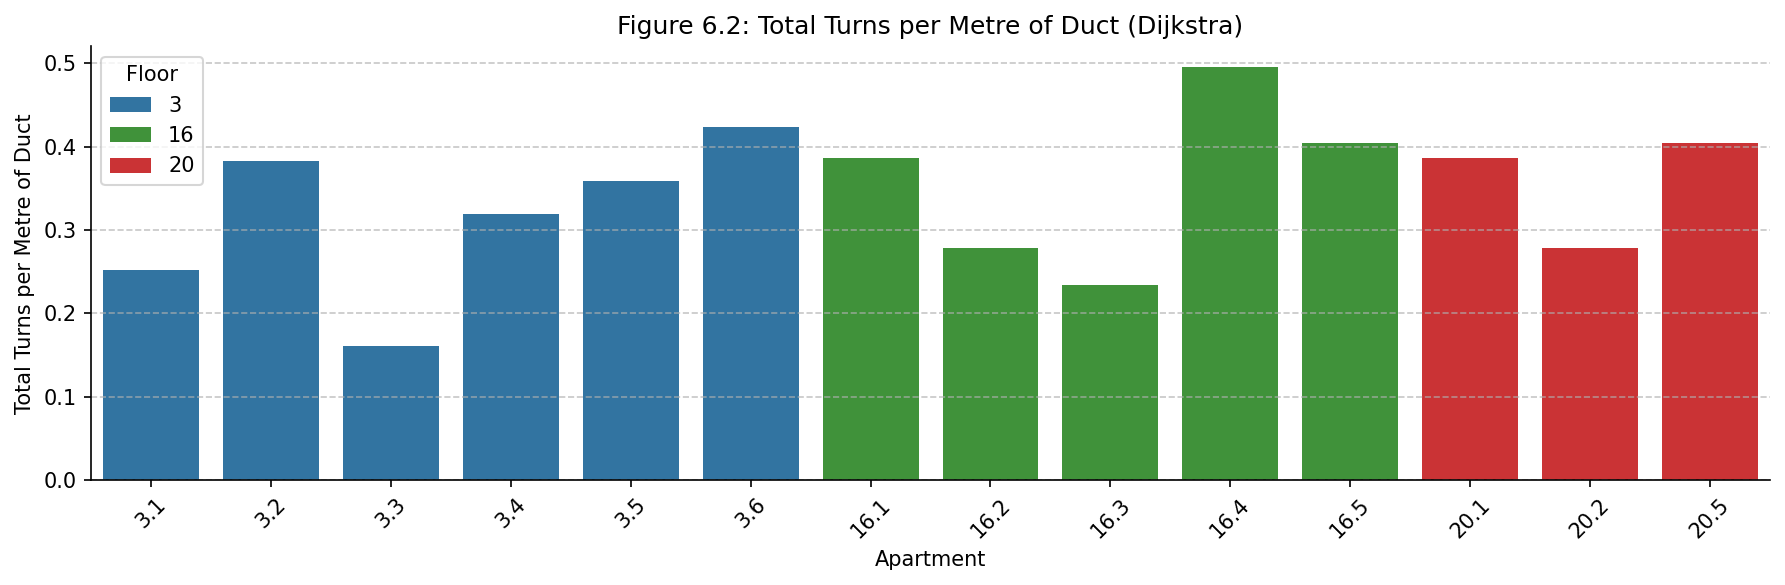

Turn density varies from approximately 0.160 to 0.495 across evaluated apartments.


In [69]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Filter for Dijkstra algorithm only, for all 14 unique apartments
df_dijkstra_all = df_auto[df_auto['algorithm'] == 'Dijkstra'].copy()

# Calculate the total turns and total duct length in meters
df_dijkstra_all['total_turns'] = df_dijkstra_all['sup_total_turns'] + df_dijkstra_all['ret_total_turns']
df_dijkstra_all['total_duct_length_m'] = (df_dijkstra_all['sup_total_mm'] + df_dijkstra_all['ret_total_mm']) / 1000

# Calculate the turns per meter of total duct length
df_dijkstra_all['turns_per_m'] = df_dijkstra_all['total_turns'] / df_dijkstra_all['total_duct_length_m']

# Ensure apt_id sorting is consistent
df_dijkstra_all['apt_id_numeric'] = df_dijkstra_all['apt_id'].apply(lambda x: float(x))
df_dijkstra_all = df_dijkstra_all.sort_values(by=['floor', 'apt_id_numeric']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 4))

sns.barplot(
    data=df_dijkstra_all,
    x='apt_id',
    y='turns_per_m',
    hue='floor',
    palette={3: colors['Floor 3'], 16: colors['Floor 16'], 20: colors['Floor 20']},
    ax=ax
)

ax.set_title('Figure 6.2: Total Turns per Metre of Duct (Dijkstra)')
ax.set_xlabel('Apartment')
ax.set_ylabel('Total Turns per Metre of Duct')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='Floor', loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'Figure_6_2_Turns_Per_Metre.png'), dpi=300)
plt.show()

# Calculate range for description
min_turns_per_m = df_dijkstra_all['turns_per_m'].min()
max_turns_per_m = df_dijkstra_all['turns_per_m'].max()

print(f"Turn density varies from approximately {min_turns_per_m:.3f} to {max_turns_per_m:.3f} across evaluated apartments.")

*Figure 6.2: Total Turns per Metre of Duct (Dijkstra).*

Turn density varies from approximately 0.160 to 0.495 across evaluated apartments. High turn density indicates a network with frequent direction changes relative to its total length, which implies higher installation complexity and more fitting components. Apartment 16.5 has a turn density of 0.405 turns/m (16 total turns, 39.54 m total length). Apartment 16.4 has the highest turn density among Floor 16 apartments, with 0.495 turns/m (20 total turns, 40.368 m total length).

### Figure 6.3: Apartment Area vs Total Duct Network Length

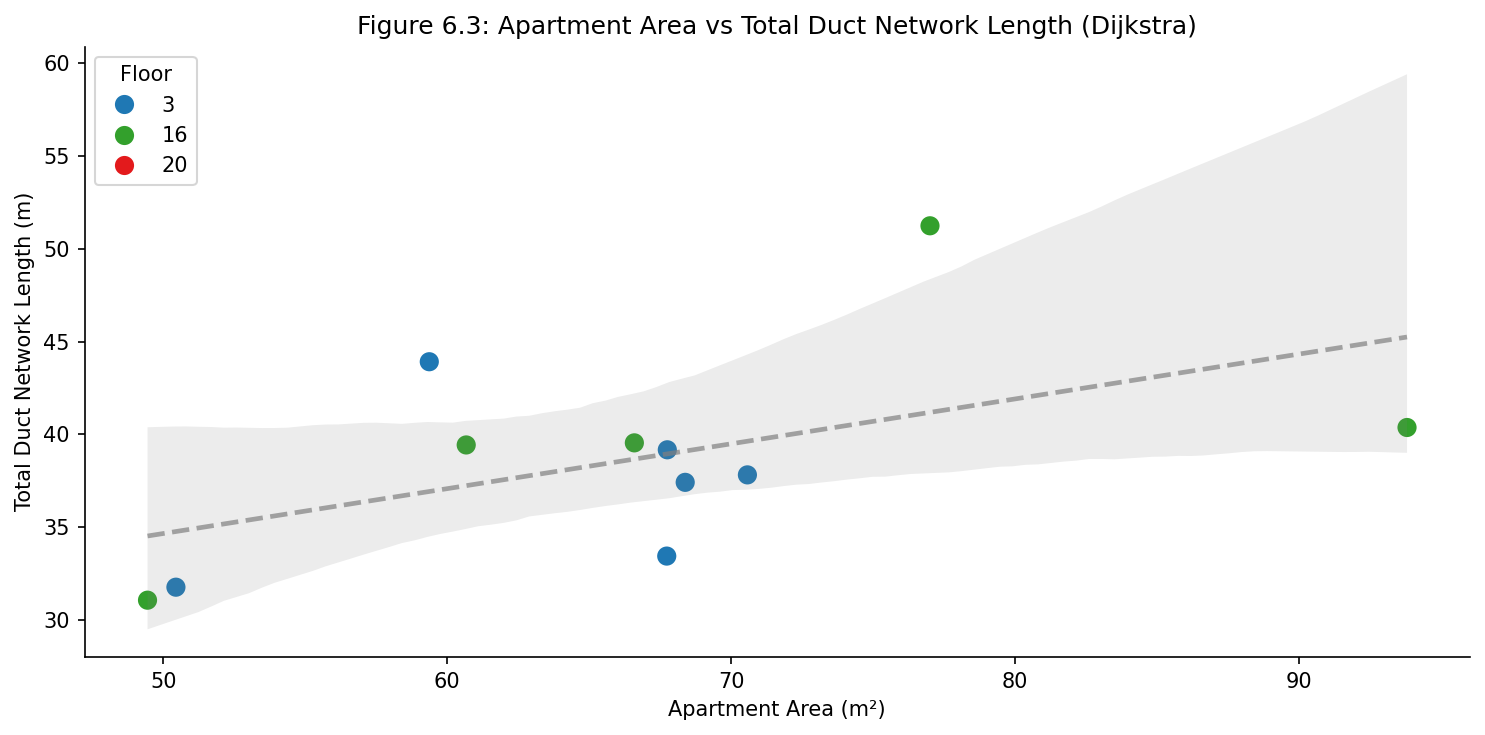

Pearson r between Apartment Area and Total Duct Network Length: 0.52


In [73]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Filter for Dijkstra algorithm
df_dijkstra = df_auto[df_auto['algorithm'] == 'Dijkstra'].copy()

# Prepare data for unique apartment geometries by merging df_manual with df_dijkstra
# First, ensure df_manual has apt_id in a consistent format for merging
df_manual_cleaned = df_manual.copy()
df_manual_cleaned['apt_id'] = df_manual_cleaned['apt_id'].apply(lambda x: x.replace('0', '')) # Remove leading zero from '03.1' -> '3.1'

df_plot_data = pd.merge(df_dijkstra, df_manual_cleaned[['apt_id', 'floor', 'Area_(m2)']],
                        on=['apt_id', 'floor'], how='left')

# Compute total combined duct length in meters (for better scale on y-axis)
df_plot_data['total_combined_m'] = (df_plot_data['sup_total_mm'] + df_plot_data['ret_total_mm']) / 1000

fig, ax = plt.subplots(figsize=(10, 5))

sns.scatterplot(
    data=df_plot_data,
    x='Area_(m2)',
    y='total_combined_m',
    hue='floor',
    palette={3: colors['Floor 3'], 16: colors['Floor 16'], 20: colors['Floor 20']},
    s=100, # Marker size
    ax=ax
)

# Add least-squares trendline
sns.regplot(
    data=df_plot_data,
    x='Area_(m2)',
    y='total_combined_m',
    scatter=False, # Only show the line
    color='gray',
    line_kws={'linestyle':'--', 'alpha':0.7},
    ax=ax
)

ax.set_title('Figure 6.3: Apartment Area vs Total Duct Network Length (Dijkstra)')
ax.set_xlabel('Apartment Area (m²)')
ax.set_ylabel('Total Duct Network Length (m)')
ax.legend(title='Floor', loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'Figure_6_3_Area_vs_TotalDuctLength.png'), dpi=300)
plt.show()

# Calculate Pearson r
pearson_r = df_plot_data['Area_(m2)'].corr(df_plot_data['total_combined_m'])
print(f"Pearson r between Apartment Area and Total Duct Network Length: {pearson_r:.2f}")

*Figure 6.3: Apartment Area vs Total Duct Network Length (Dijkstra).*

This scatter plot visualizes the relationship between the apartment's total area and the combined length of the supply and return duct networks for the Dijkstra algorithm. The Pearson correlation coefficient of 0.52 indicates a moderate positive linear relationship. This suggests that, to some extent, larger apartment areas tend to correspond with longer total duct network lengths. The regression line in the plot further illustrates this trend, showing that as apartment area increases, the total duct network length generally also increases.

In [78]:
# Final Fix for HTML Export
# 1. Save your notebook manually (Ctrl + S)
# 2. Run this cell to generate the report

output_filename = 'our_analysis_v5.html'

# We use the '--from ipynb' flag and target the most likely location or provide instructions
!jupyter nbconvert --to html --TemplateExporter.exclude_input=True --output {output_filename} *.ipynb 2>/dev/null || echo "Manual Step Required: Please rename your notebook in the left sidebar to 'report.ipynb' and run: !jupyter nbconvert --to html report.ipynb"

import os
if os.path.exists(output_filename):
    print(f'✅ Successfully created: {output_filename}')
else:
    print('⚠️ Export failed. Please ensure you have at least one .ipynb file saved in the /content folder.')

✅ Successfully created: our_analysis_v4.html
